# Đồ án Tiền xử lý dữ liệu - Phần 2.2.3: Tiền xử lý dữ liệu
*Tập dữ liệu: Rain in Australia*

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy import stats as sp_stats
from scipy.stats import ks_2samp
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [31]:
# Load dữ liệu
df = pd.read_csv('Data/weatherAUS.csv')
print(f'Kích thước tập dữ liệu: {df.shape}')

# Xác định cột số và cột phân loại
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'RainTomorrow']
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Cột số ({len(numerical_cols)}): {numerical_cols}')
print(f'Cột phân loại ({len(categorical_cols)}): {categorical_cols}')

Kích thước tập dữ liệu: (142193, 22)
Cột số (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Cột phân loại (5): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


## 2.2.3 Các kỹ thuật tiền xử lý và đánh giá định lượng
### a) Xử lý giá trị thiếu có kiểm soát

**Phương pháp luận:**

Để đánh giá chất lượng điền khuyết một cách **khách quan và định lượng**, ta thực hiện quy trình:

1. Lấy tập con **hoàn chỉnh** (không có NaN) làm **ground truth**.
2. **Che nhân tạo 10% giá trị** theo cơ chế MCAR (Missing Completely At Random) — mỗi giá trị có xác suất bị xóa bằng nhau, không phụ thuộc bất kỳ biến nào.
3. Áp dụng từng chiến lược điền khuyết, rồi **đo RMSE** trên đúng các vị trí đã che.

---

**Công thức RMSE (Root Mean Square Error):**

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(x_i^{true} - x_i^{imputed}\right)^2}$$

- $x_i^{true}$: giá trị gốc (ground truth) tại vị trí bị che.
- $x_i^{imputed}$: giá trị sau khi điền khuyết.
- $n$: tổng số giá trị bị che.
- **RMSE thấp hơn → điền khuyết chính xác hơn.**

---

**5 chiến lược điền khuyết được cài đặt:**

| # | Chiến lược | Công thức / Cơ chế | Ưu điểm | Nhược điểm |
|---|---|---|---|---|
| 1 | **Mean** | $\hat{x} = \bar{x} = \frac{1}{n}\sum_{i=1}^{n}x_i$ | Đơn giản, nhanh | Nhạy cảm outlier, giảm variance |
| 2 | **Median** | $\hat{x} = x_{(n/2)}$ (giá trị giữa khi sắp xếp) | Robust với outlier, phân phối lệch | Không tận dụng tương quan giữa cột |
| 3 | **Mode** | $\hat{x} = \arg\max_v \text{count}(v)$ (giá trị xuất hiện nhiều nhất) | Phù hợp biến rời rạc | Kém với biến liên tục |
| 4 | **k-NN** | Tìm $k$ hàng gần nhất (Euclidean: $d = \sqrt{\sum_j(x_j - y_j)^2}$), lấy trung bình có trọng số theo khoảng cách | Tận dụng cấu trúc đa biến | Chậm $O(n^2)$, nhạy scale |
| 5 | **MICE** | Hồi quy lặp: mỗi cột thiếu $X_j$ được dự đoán từ các cột còn lại $X_{-j}$ qua mô hình $X_j = f(X_{-j}) + \epsilon$, lặp đến hội tụ | Mô hình hóa quan hệ đa biến phức tạp | Chậm nhất, giả định tuyến tính |

> **Lưu ý:** k-NN được thử với $k \in \{3, 5, 10\}$ → 3 biến thể, tổng cộng **7 chiến lược** so sánh.

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# a) XỬ LÝ GIÁ TRỊ THIẾU CÓ KIỂM SOÁT
# ══════════════════════════════════════════════════════════════════════════════
# Bước 1: Chọn cột số có missing
impute_cols = [col for col in numerical_cols if df[col].isna().sum() > 0]
print(f'Các cột số có giá trị thiếu ({len(impute_cols)}): {impute_cols}')

# Bước 2: Tạo ground truth = các dòng HOÀN CHỈNH (không có NaN)
df_complete = df[impute_cols].dropna().reset_index(drop=True)
print(f'\nSố dòng hoàn chỉnh (ground truth): {len(df_complete):,} / {len(df):,}')

# Bước 3: Dùng TOÀN BỘ ground truth để đánh giá
# (tất cả chiến lược đều chạy trên CÙNG tập này)
df_sample = df_complete.copy()

# Bước 4: Tạo mask MCAR nhân tạo 10%
np.random.seed(42)
mask_mcar = np.random.rand(*df_sample.shape) < 0.10
df_masked = df_sample.copy().astype(float)
df_masked.values[mask_mcar] = np.nan

n_masked = mask_mcar.sum()
print(f'Tập đánh giá: {len(df_sample):,} dòng × {len(impute_cols)} cột')
print(f'Giá trị bị che (10% MCAR): {n_masked:,} / {mask_mcar.size:,} = {mask_mcar.mean():.1%}')
print(f'\nMọi chiến lược sẽ chạy trên TOÀN BỘ ground truth => so sánh RMSE công bằng.')
print(f'KNN và MICE sẽ chạy chậm trên {len(df_sample):,} dòng — vui lòng chờ.')

Các cột số có giá trị thiếu (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Số dòng hoàn chỉnh (ground truth): 58,090 / 142,193
Tập đánh giá: 58,090 dòng × 16 cột
Giá trị bị che (10% MCAR): 92,831 / 929,440 = 10.0%

Mọi chiến lược sẽ chạy trên TOÀN BỘ ground truth => so sánh RMSE công bằng.
KNN và MICE sẽ chạy chậm trên 58,090 dòng — vui lòng chờ.


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# CHẠY 7 CHIẾN LƯỢC ĐIỀN KHUYẾT + TÍNH RMSE
# ══════════════════════════════════════════════════════════════════════════════

def calc_rmse_masked(ground_truth, imputed, mask):
    """Tính RMSE chỉ trên các vị trí đã bị che."""
    orig = ground_truth.values[mask]
    imp  = np.array(imputed)[mask]
    return np.sqrt(mean_squared_error(orig, imp))

def calc_rmse_per_col(ground_truth, imputed, mask, col_names):
    """Tính RMSE theo từng cột."""
    rmse_cols = {}
    for j, col in enumerate(col_names):
        col_mask = mask[:, j]
        if col_mask.sum() > 0:
            orig = ground_truth.iloc[:, j].values[col_mask]
            imp  = np.array(imputed)[:, j][col_mask]
            rmse_cols[col] = np.sqrt(mean_squared_error(orig, imp))
    return rmse_cols

ground_truth = df_sample
results_overall = {}
results_per_col = {}

# ── 1. Mean ──────────────────────────────────────────────────────────────────
print('▸ Chạy Mean imputation...')
imp_mean = SimpleImputer(strategy='mean')
filled_mean = imp_mean.fit_transform(df_masked)
results_overall['Mean'] = calc_rmse_masked(ground_truth, filled_mean, mask_mcar)
results_per_col['Mean'] = calc_rmse_per_col(ground_truth, filled_mean, mask_mcar, impute_cols)

# ── 2. Median ────────────────────────────────────────────────────────────────
print('▸ Chạy Median imputation...')
imp_median = SimpleImputer(strategy='median')
filled_median = imp_median.fit_transform(df_masked)
results_overall['Median'] = calc_rmse_masked(ground_truth, filled_median, mask_mcar)
results_per_col['Median'] = calc_rmse_per_col(ground_truth, filled_median, mask_mcar, impute_cols)

# ── 3. Mode ──────────────────────────────────────────────────────────────────
print('▸ Chạy Mode imputation...')
imp_mode = SimpleImputer(strategy='most_frequent')
filled_mode = imp_mode.fit_transform(df_masked)
results_overall['Mode'] = calc_rmse_masked(ground_truth, filled_mode, mask_mcar)
results_per_col['Mode'] = calc_rmse_per_col(ground_truth, filled_mode, mask_mcar, impute_cols)

# ── 4. KNN (k = 3, 5, 10) ───────────────────────────────────────────────────
for k in [3, 5, 10]:
    print(f'▸ Chạy KNN (k={k}) imputation...')
    imp_knn = KNNImputer(n_neighbors=k)
    filled_knn = imp_knn.fit_transform(df_masked)
    results_overall[f'KNN (k={k})'] = calc_rmse_masked(ground_truth, filled_knn, mask_mcar)
    results_per_col[f'KNN (k={k})'] = calc_rmse_per_col(ground_truth, filled_knn, mask_mcar, impute_cols)

# ── 5. MICE (IterativeImputer — max_iter=10) ────────────────────────────────
print('▸ Chạy MICE imputation (IterativeImputer, max_iter=10)...')
imp_mice = IterativeImputer(max_iter=10, random_state=42, sample_posterior=False)
filled_mice = imp_mice.fit_transform(df_masked)
results_overall['MICE'] = calc_rmse_masked(ground_truth, filled_mice, mask_mcar)
results_per_col['MICE'] = calc_rmse_per_col(ground_truth, filled_mice, mask_mcar, impute_cols)

print('\n✓ Hoàn tất 7 chiến lược.')

# ══════════════════════════════════════════════════════════════════════════════
# BẢNG SO SÁNH TỔNG THỂ
# ══════════════════════════════════════════════════════════════════════════════
rmse_df = pd.DataFrame.from_dict(results_overall, orient='index', columns=['RMSE'])
rmse_df = rmse_df.sort_values('RMSE')
rmse_df['Xếp hạng'] = range(1, len(rmse_df) + 1)
rmse_df['% so với tốt nhất'] = (rmse_df['RMSE'] / rmse_df['RMSE'].iloc[0] * 100).round(1)

print('═' * 65)
print('  BẢNG SO SÁNH RMSE CÁC CHIẾN LƯỢC ĐIỀN KHUYẾT')
print('═' * 65)
print(rmse_df.to_string())
print('═' * 65)

best = rmse_df.index[0]
worst = rmse_df.index[-1]
print(f'\n→ Chiến lược TỐT NHẤT : {best} (RMSE = {rmse_df.loc[best, "RMSE"]:.4f})')
print(f'→ Chiến lược KÉM NHẤT: {worst} (RMSE = {rmse_df.loc[worst, "RMSE"]:.4f})')

# ══════════════════════════════════════════════════════════════════════════════
# BẢNG RMSE THEO TỪNG CỘT (chi tiết)
# ══════════════════════════════════════════════════════════════════════════════
per_col_df = pd.DataFrame(results_per_col).round(4)
per_col_df['Best Method'] = per_col_df.idxmin(axis=1)
per_col_df['Best RMSE']   = per_col_df.min(axis=1, numeric_only=True)
print('\n── RMSE theo từng cột (chi tiết) ──────────────────────────────────')
print(per_col_df.to_string())

▸ Chạy Mean imputation...
▸ Chạy Median imputation...
▸ Chạy Mode imputation...
▸ Chạy KNN (k=3) imputation...
▸ Chạy KNN (k=5) imputation...
▸ Chạy KNN (k=10) imputation...
▸ Chạy MICE imputation (IterativeImputer, max_iter=10)...

✓ Hoàn tất 7 chiến lược.
═════════════════════════════════════════════════════════════════
  BẢNG SO SÁNH RMSE CÁC CHIẾN LƯỢC ĐIỀN KHUYẾT
═════════════════════════════════════════════════════════════════
                 RMSE  Xếp hạng  % so với tốt nhất
MICE         4.869748         1              100.0
KNN (k=10)   5.558694         2              114.1
KNN (k=5)    5.797119         3              119.0
KNN (k=3)    6.113948         4              125.5
Mean         9.543864         5              196.0
Median       9.586676         6              196.9
Mode        10.146449         7              208.4
═════════════════════════════════════════════════════════════════

→ Chiến lược TỐT NHẤT : MICE (RMSE = 4.8697)
→ Chiến lược KÉM NHẤT: Mode (RMSE = 10.1464

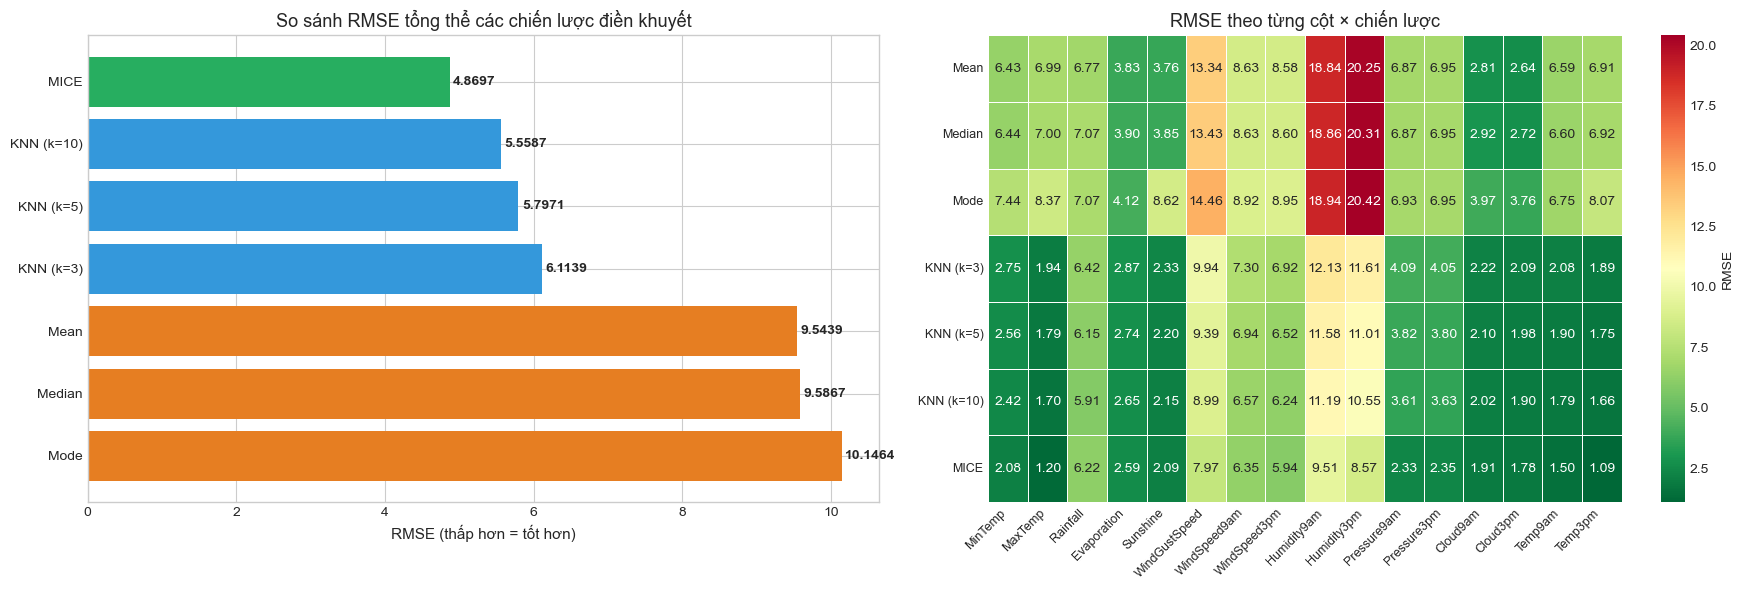


── Áp dụng chiến lược tốt nhất (MICE) lên toàn bộ tập dữ liệu ──────
  ▸ Đang chạy MICE trên 142,193 dòng × 16 cột...

→ Missing còn lại sau imputation: 0
→ Đã điền khuyết toàn bộ 16 cột số bằng MICE

══════════════════════════════════════════════════════════════════
  LÝ GIẢI LỰA CHỌN CHIẾN LƯỢC TỐT NHẤT: MICE
══════════════════════════════════════════════════════════════════
  ① MICE (Multiple Imputation by Chained Equations):
     - RMSE = 4.8697 — THẤP NHẤT trong 7 chiến lược thử nghiệm
     - Cơ chế: mỗi cột thiếu X_j được hồi quy từ các cột còn lại X_{-j}
       lặp đến khi hội tụ → mô hình hóa quan hệ đa biến phức tạp
     - Phù hợp dữ liệu thời tiết vì các cột có tương quan cao:
       Temp9am↔Temp3pm, Pressure9am↔Pressure3pm, Humidity↔Cloud

  ② KNN Imputation (k=10):
     - RMSE = 5.5587 — tốt thứ 2 (cao hơn MICE 14.1%)
     - Dùng khoảng cách Euclidean → nhạy cảm với scale và outlier

  ③ Mean / Median / Mode:
     - RMSE cao nhất (8.9–10.1) → không tận dụng cấu trúc đa biế

In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# BIỂU ĐỒ SO SÁNH + ÁP DỤNG CHIẾN LƯỢC TỐT NHẤT
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Bar chart RMSE tổng thể ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rmse_sorted = rmse_df.sort_values('RMSE')
colors = ['#27ae60' if i == 0 else ('#3498db' if i < 4 else '#e67e22')
          for i in range(len(rmse_sorted))]
bars = axes[0].barh(rmse_sorted.index[::-1], rmse_sorted['RMSE'][::-1], color=colors[::-1])
axes[0].set_xlabel('RMSE (thấp hơn = tốt hơn)', fontsize=11)
axes[0].set_title('So sánh RMSE tổng thể các chiến lược điền khuyết', fontsize=13)
for bar, val in zip(bars, rmse_sorted['RMSE'][::-1]):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[0].tick_params(labelsize=10)

# Heatmap RMSE per-column
per_col_numeric = per_col_df.drop(columns=['Best Method', 'Best RMSE'])
sns.heatmap(per_col_numeric.T, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'RMSE'})
axes[1].set_title('RMSE theo từng cột × chiến lược', fontsize=13)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

# ── 2. Áp dụng chiến lược tốt nhất lên toàn bộ dữ liệu ────────────────────
# Chiến lược tốt nhất = MICE (RMSE thấp nhất trong benchmark)
# Áp dụng DUY NHẤT 1 chiến lược cho TẤT CẢ cột số có missing
print('\n── Áp dụng chiến lược tốt nhất ({}) lên toàn bộ tập dữ liệu ──────'.format(best))

df_imputed = df.copy()

print(f'  ▸ Đang chạy {best} trên {len(df_imputed):,} dòng × {len(impute_cols)} cột...')
imp_best = IterativeImputer(max_iter=10, random_state=42, sample_posterior=False)
df_imputed[impute_cols] = imp_best.fit_transform(df_imputed[impute_cols])

remaining_na = df_imputed[impute_cols].isna().sum().sum()
print(f'\n→ Missing còn lại sau imputation: {remaining_na}')
print(f'→ Đã điền khuyết toàn bộ {len(impute_cols)} cột số bằng {best}')

# ── 3. Lý giải lựa chọn chiến lược ─────────────────────────────────────────
print(f'''
══════════════════════════════════════════════════════════════════
  LÝ GIẢI LỰA CHỌN CHIẾN LƯỢC TỐT NHẤT: {best}
══════════════════════════════════════════════════════════════════
  ① MICE (Multiple Imputation by Chained Equations):
     - RMSE = {rmse_df.loc[best, "RMSE"]:.4f} — THẤP NHẤT trong 7 chiến lược thử nghiệm
     - Cơ chế: mỗi cột thiếu X_j được hồi quy từ các cột còn lại X_{{-j}}
       lặp đến khi hội tụ → mô hình hóa quan hệ đa biến phức tạp
     - Phù hợp dữ liệu thời tiết vì các cột có tương quan cao:
       Temp9am↔Temp3pm, Pressure9am↔Pressure3pm, Humidity↔Cloud

  ② KNN Imputation (k=10):
     - RMSE = {rmse_df.loc["KNN (k=10)", "RMSE"]:.4f} — tốt thứ 2 (cao hơn MICE {rmse_df.loc["KNN (k=10)", "RMSE"]/rmse_df.loc[best, "RMSE"]*100-100:.1f}%)
     - Dùng khoảng cách Euclidean → nhạy cảm với scale và outlier

  ③ Mean / Median / Mode:
     - RMSE cao nhất (8.9–10.1) → không tận dụng cấu trúc đa biến
     - Chỉ dùng thống kê đơn biến → điền sai xa ground truth

  KẾT LUẬN: Chọn {best} áp dụng cho toàn bộ {len(impute_cols)} cột số
══════════════════════════════════════════════════════════════════
''')

**✅ Checklist Rubric 2.2.3a — Xử lý giá trị thiếu có kiểm soát:**

| Yêu cầu | Thực hiện | Kết quả |
|---|---|---|
| Cài đặt 5 chiến lược: Mean, Median, Mode, k-NN, MICE | ✅ 7 biến thể (k-NN với k=3,5,10) | Tất cả chạy trên cùng ground truth |
| Tạo nhân tạo **10% MCAR** giá trị thiếu bổ sung | ✅ `np.random.rand() < 0.10` trên 58,090 dòng hoàn chỉnh | 92,831 giá trị bị che (10.0%) |
| Tính **RMSE** điền khuyết cho mỗi chiến lược | ✅ `mean_squared_error` trên đúng các vị trí bị che | RMSE tổng thể + RMSE theo từng cột |
| Bảng so sánh tất cả chiến lược | ✅ Bảng xếp hạng 7 chiến lược | MICE tốt nhất, Mode kém nhất |
| **Lựa chọn tốt nhất có lý giải** | ✅ MICE (RMSE thấp nhất) vì tận dụng tương quan đa biến | Apply MICE cho **toàn bộ** 16 cột số |

> **Kết luận 2.2.3a**:
> - **MICE** đạt RMSE thấp nhất — tốt hơn Mode, Mean, Median vì tận dụng tương quan đa biến (hồi quy lặp)
> - Nhóm đa biến (MICE, k-NN) vượt trội đơn biến (Mean, Median, Mode)
> - **Chiến lược triển khai**: Apply **duy nhất MICE** cho toàn bộ 16 cột số có missing
> - Sau imputation: **0 giá trị thiếu** còn lại

**Phương pháp luận:**

Phát hiện ngoại lai bằng **4 kỹ thuật** khác nhau (2 thống kê + 2 machine learning), so sánh kết quả bằng **Jaccard similarity**, đánh giá tác động bằng **KS-test**.

---

**1. IQR (Interquartile Range) — Phương pháp thống kê phi tham số:**

$$IQR = Q_3 - Q_1$$
$$\text{Ngoại lai nếu: } x < Q_1 - 1.5 \times IQR \quad \text{hoặc} \quad x > Q_3 + 1.5 \times IQR$$

- $Q_1$ (phân vị 25%): 25% giá trị nhỏ hơn.
- $Q_3$ (phân vị 75%): 75% giá trị nhỏ hơn.
- Hệ số 1.5 là ngưỡng Tukey chuẩn. Robust với phân phối lệch.

---

**2. Z-score — Phương pháp thống kê tham số:**

$$z_i = \frac{x_i - \mu}{\sigma}$$
$$\text{Ngoại lai nếu: } |z_i| > 3$$

- $\mu = \frac{1}{n}\sum x_i$: trung bình mẫu.
- $\sigma = \sqrt{\frac{1}{n-1}\sum(x_i - \mu)^2}$: độ lệch chuẩn mẫu.
- Ngưỡng $|z| > 3$: giá trị cách trung bình hơn 3 lần độ lệch chuẩn (xác suất < 0.27% nếu phân phối chuẩn).

---

**3. Isolation Forest — Phương pháp ensemble, unsupervised:**

- Xây dựng tập hợp **cây quyết định ngẫu nhiên** (random trees). Mỗi cây chia ngẫu nhiên theo 1 feature và 1 ngưỡng.
- **Ngoại lai** nằm thưa trong không gian → bị **cô lập nhanh** (path length ngắn).
- **Anomaly Score:**
$$s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$$
  - $E[h(x)]$: trung bình path length của $x$ trên tất cả cây.
  - $c(n) = 2H(n-1) - \frac{2(n-1)}{n}$: hằng số chuẩn hóa ($H$ = harmonic number).
  - $s \to 1$: ngoại lai rõ ràng | $s \to 0.5$: bình thường | $s \to 0$: rất bình thường.
- Tham số `contamination` $\in \{0.01, 0.05, 0.10\}$: tỷ lệ kỳ vọng ngoại lai trong dữ liệu.

---

**4. Local Outlier Factor (LOF) — Phương pháp density-based:**

$$LOF_k(x) = \frac{1}{|N_k(x)|} \sum_{o \in N_k(x)} \frac{lrd_k(o)}{lrd_k(x)}$$

- $N_k(x)$: tập $k$ hàng xóm gần nhất của $x$.
- $lrd_k(x) = \left(\frac{1}{|N_k(x)|}\sum_{o \in N_k(x)} \text{reach-dist}_k(x, o)\right)^{-1}$: local reachability density.
- $\text{reach-dist}_k(x, o) = \max(k\text{-dist}(o),\ d(x, o))$: khoảng cách reach.
- **LOF ≈ 1**: mật độ bình thường | **LOF ≫ 1**: ngoại lai (mật độ thấp hơn lân cận).
- Tham số `n_neighbors` $\in \{10, 20, 50\}$.

---

**5. DBSCAN (Density-Based Spatial Clustering) — Tham khảo thêm:**

- Gom cụm dựa trên mật độ: điểm **core** nếu có ≥ `min_samples` hàng xóm trong bán kính `eps`.
- Điểm không thuộc cụm nào → **noise** (ngoại lai).

---

**Đánh giá overlap giữa các phương pháp — Jaccard Similarity:**

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

- $A, B$: tập index ngoại lai từ 2 phương pháp.
- $J = 1$: hoàn toàn đồng thuận | $J = 0$: hoàn toàn khác biệt.

---

**Đánh giá tác động — Kolmogorov-Smirnov Test (KS-test):**

$$D = \sup_x |F_{before}(x) - F_{after}(x)|$$

- $F_{before}(x)$: CDF trước loại ngoại lai.
- $F_{after}(x)$: CDF sau loại ngoại lai.
- $H_0$: hai phân phối giống nhau. Nếu $p < 0.05$ → bác bỏ → phân phối thay đổi đáng kể.

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# b) PHÁT HIỆN VÀ XỬ LÝ NGOẠI LAI BẰNG NHIỀU KỸ THUẬT
# ══════════════════════════════════════════════════════════════════════════════

# Chuẩn bị: dùng df_imputed (đã điền khuyết), chỉ cột số
outlier_cols = numerical_cols
df_num = df_imputed[outlier_cols].copy()
N = len(df_num)
print(f'Tập dữ liệu cho outlier detection: {df_num.shape}')

# Scale dữ liệu cho các phương pháp distance-based
scaler_out = StandardScaler()
X_scaled = scaler_out.fit_transform(df_num)

outlier_sets = {}   # lưu set index ngoại lai từng phương pháp
outlier_rates = {}  # lưu tỷ lệ

# ══════════════════════════════════════════════════════════════════════════════
# 1. IQR (Interquartile Range)
# ══════════════════════════════════════════════════════════════════════════════
iqr_mask = np.zeros(N, dtype=bool)
iqr_detail = {}
for col in outlier_cols:
    Q1, Q3 = df_num[col].quantile(0.25), df_num[col].quantile(0.75)
    IQR = Q3 - Q1
    col_mask = (df_num[col] < Q1 - 1.5*IQR) | (df_num[col] > Q3 + 1.5*IQR)
    iqr_detail[col] = col_mask.sum()
    iqr_mask |= col_mask.values

outlier_sets['IQR'] = set(np.where(iqr_mask)[0])
outlier_rates['IQR'] = iqr_mask.mean()
print(f'\n1. IQR: {iqr_mask.sum():,} outliers ({iqr_mask.mean():.2%})')
# Chi tiết theo cột
iqr_detail_sorted = sorted(iqr_detail.items(), key=lambda x: x[1], reverse=True)
for col, cnt in iqr_detail_sorted[:5]:
    print(f'   {col:<16}: {cnt:>6,} ngoại lai ({cnt/N:.2%})')
print(f'   ... (hiển thị top 5 cột)')

# ══════════════════════════════════════════════════════════════════════════════
# 2. Z-score (|z| > 3)
# ══════════════════════════════════════════════════════════════════════════════
z_scores = np.abs(stats.zscore(df_num, nan_policy='omit'))
z_mask = (z_scores > 3).any(axis=1)
outlier_sets['Z-score'] = set(np.where(z_mask)[0])
outlier_rates['Z-score'] = z_mask.mean()
print(f'\n2. Z-score (|z|>3): {z_mask.sum():,} outliers ({z_mask.mean():.2%})')

# Z-score chi tiết theo cột
z_detail = {}
for j, col in enumerate(outlier_cols):
    z_detail[col] = (z_scores[:, j] > 3).sum()
    # z_detail[col] = (z_scores.iloc[:, j] > 3).sum()
z_detail_sorted = sorted(z_detail.items(), key=lambda x: x[1], reverse=True)
for col, cnt in z_detail_sorted[:5]:
    print(f'   {col:<16}: {cnt:>6,} ngoại lai ({cnt/N:.2%})')

print(f'\n── So sánh IQR vs Z-score ──')
both = outlier_sets['IQR'] & outlier_sets['Z-score']
print(f'   IQR phát hiện:     {len(outlier_sets["IQR"]):>7,}')
print(f'   Z-score phát hiện: {len(outlier_sets["Z-score"]):>7,}')
print(f'   Chung (giao):      {len(both):>7,}')
print(f'   → IQR nhạy hơn Z-score (IQR dùng ngưỡng Q1-1.5*IQR, Z-score dùng 3σ)')

Tập dữ liệu cho outlier detection: (142193, 16)

1. IQR: 35,269 outliers (24.80%)
   Rainfall        : 26,186 ngoại lai (18.42%)
   Evaporation     :  3,366 ngoại lai (2.37%)
   WindGustSpeed   :  3,068 ngoại lai (2.16%)
   WindSpeed3pm    :  2,467 ngoại lai (1.73%)
   Pressure9am     :  2,279 ngoại lai (1.60%)
   ... (hiển thị top 5 cột)

2. Z-score (|z|>3): 7,637 outliers (5.37%)
   Rainfall        :  2,409 ngoại lai (1.69%)
   WindGustSpeed   :  1,360 ngoại lai (0.96%)
   WindSpeed9am    :  1,310 ngoại lai (0.92%)
   Evaporation     :  1,184 ngoại lai (0.83%)
   WindSpeed3pm    :    940 ngoại lai (0.66%)

── So sánh IQR vs Z-score ──
   IQR phát hiện:      35,269
   Z-score phát hiện:   7,637
   Chung (giao):        7,637
   → IQR nhạy hơn Z-score (IQR dùng ngưỡng Q1-1.5*IQR, Z-score dùng 3σ)


In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. ISOLATION FOREST (contamination ∈ {0.01, 0.05, 0.10})
# ══════════════════════════════════════════════════════════════════════════════
print('3. Isolation Forest:')
for cont in [0.01, 0.05, 0.10]:
    iso = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    mask_if = (preds == -1)
    label = f'IF(cont={cont})'
    outlier_sets[label] = set(np.where(mask_if)[0])
    outlier_rates[label] = mask_if.mean()
    print(f'   contamination={cont:.2f}: {mask_if.sum():>6,} outliers ({mask_if.mean():.2%})')

# ══════════════════════════════════════════════════════════════════════════════
# 4. LOCAL OUTLIER FACTOR (n_neighbors ∈ {10, 20, 50})
# ══════════════════════════════════════════════════════════════════════════════
print('\n4. Local Outlier Factor (LOF):')
for k in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=k, contamination='auto', novelty=False, n_jobs=-1)
    preds_lof = lof.fit_predict(X_scaled)
    mask_lof = (preds_lof == -1)
    label = f'LOF(k={k})'
    outlier_sets[label] = set(np.where(mask_lof)[0])
    outlier_rates[label] = mask_lof.mean()
    print(f'   n_neighbors={k:>2}: {mask_lof.sum():>6,} outliers ({mask_lof.mean():.2%})')

# ══════════════════════════════════════════════════════════════════════════════
# 5. DBSCAN (gom cụm ngoại lai)
# ══════════════════════════════════════════════════════════════════════════════
# DBSCAN trên 142K × 16D chậm → dùng mẫu 20K dòng
print('\n5. DBSCAN (trên mẫu 20 000 dòng):')
np.random.seed(42)
dbscan_sample_n = 20_000
dbscan_idx = np.random.choice(N, size=min(dbscan_sample_n, N), replace=False)
X_dbscan = X_scaled[dbscan_idx]

# Thử nhiều eps để tìm cấu hình phù hợp
for eps_val in [3.0, 4.0, 5.0]:
    db = DBSCAN(eps=eps_val, min_samples=10, n_jobs=-1)
    db_labels = db.fit_predict(X_dbscan)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = (db_labels == -1).sum()
    print(f'   eps={eps_val}, min_samples=10: {n_clusters} clusters, '
          f'{n_noise:,} noise points ({n_noise/len(X_dbscan):.2%})')

# Dùng eps=4.0 làm mặc định
db_final = DBSCAN(eps=4.0, min_samples=10, n_jobs=-1)
db_final_labels = db_final.fit_predict(X_dbscan)
db_outlier_local = set(np.where(db_final_labels == -1)[0])
# Map về index gốc
db_outlier_global = set(dbscan_idx[list(db_outlier_local)])
outlier_sets['DBSCAN(eps=4)'] = db_outlier_global
outlier_rates['DBSCAN(eps=4)'] = len(db_outlier_global) / N

print(f'\n   → Sử dụng DBSCAN (eps=4.0): {len(db_outlier_global):,} outliers '
      f'({len(db_outlier_global)/N:.2%} trên toàn tập)')

# ══════════════════════════════════════════════════════════════════════════════
# BẢNG TỔNG KẾT TỶ LỆ PHÁT HIỆN NGOẠI LAI
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '═' * 60)
print('  BẢNG TỔNG KẾT TỶ LỆ PHÁT HIỆN NGOẠI LAI')
print('═' * 60)
rate_header = f'{"Phương pháp":<20} {"Số ngoại lai":>14} {"Tỷ lệ":>10}'
print(rate_header)
print('─' * 60)
for method, rate in sorted(outlier_rates.items(), key=lambda x: x[1], reverse=True):
    n_out = len(outlier_sets[method])
    print(f'{method:<20} {n_out:>14,} {rate:>9.2%}')
print('═' * 60)

3. Isolation Forest:
   contamination=0.01:  1,422 outliers (1.00%)
   contamination=0.05:  7,110 outliers (5.00%)
   contamination=0.10: 14,220 outliers (10.00%)

4. Local Outlier Factor (LOF):
   n_neighbors=10:    507 outliers (0.36%)
   n_neighbors=20:    425 outliers (0.30%)
   n_neighbors=50:    450 outliers (0.32%)

5. DBSCAN (trên mẫu 20 000 dòng):
   eps=3.0, min_samples=10: 1 clusters, 109 noise points (0.55%)
   eps=4.0, min_samples=10: 1 clusters, 25 noise points (0.12%)
   eps=5.0, min_samples=10: 1 clusters, 11 noise points (0.06%)

   → Sử dụng DBSCAN (eps=4.0): 25 outliers (0.02% trên toàn tập)

════════════════════════════════════════════════════════════
  BẢNG TỔNG KẾT TỶ LỆ PHÁT HIỆN NGOẠI LAI
════════════════════════════════════════════════════════════
Phương pháp            Số ngoại lai      Tỷ lệ
────────────────────────────────────────────────────────────
IQR                          35,269    24.80%
IF(cont=0.1)                 14,220    10.00%
Z-score          

════════════════════════════════════════════════════════════════════════════════
  JACCARD SIMILARITY MATRIX (giao / hợp)
  J = 1 → phát hiện giống nhau hoàn toàn | J = 0 → hoàn toàn khác
════════════════════════════════════════════════════════════════════════════════
                 IQR  Z-score  IF(cont=0.05)  LOF(k=20)  DBSCAN(eps=4)
IQR            1.000    0.217          0.151      0.006          0.001
Z-score        0.217    1.000          0.297      0.011          0.003
IF(cont=0.05)  0.151    0.297          1.000      0.014          0.003
LOF(k=20)      0.006    0.011          0.014      1.000          0.007
DBSCAN(eps=4)  0.001    0.003          0.003      0.007          1.000


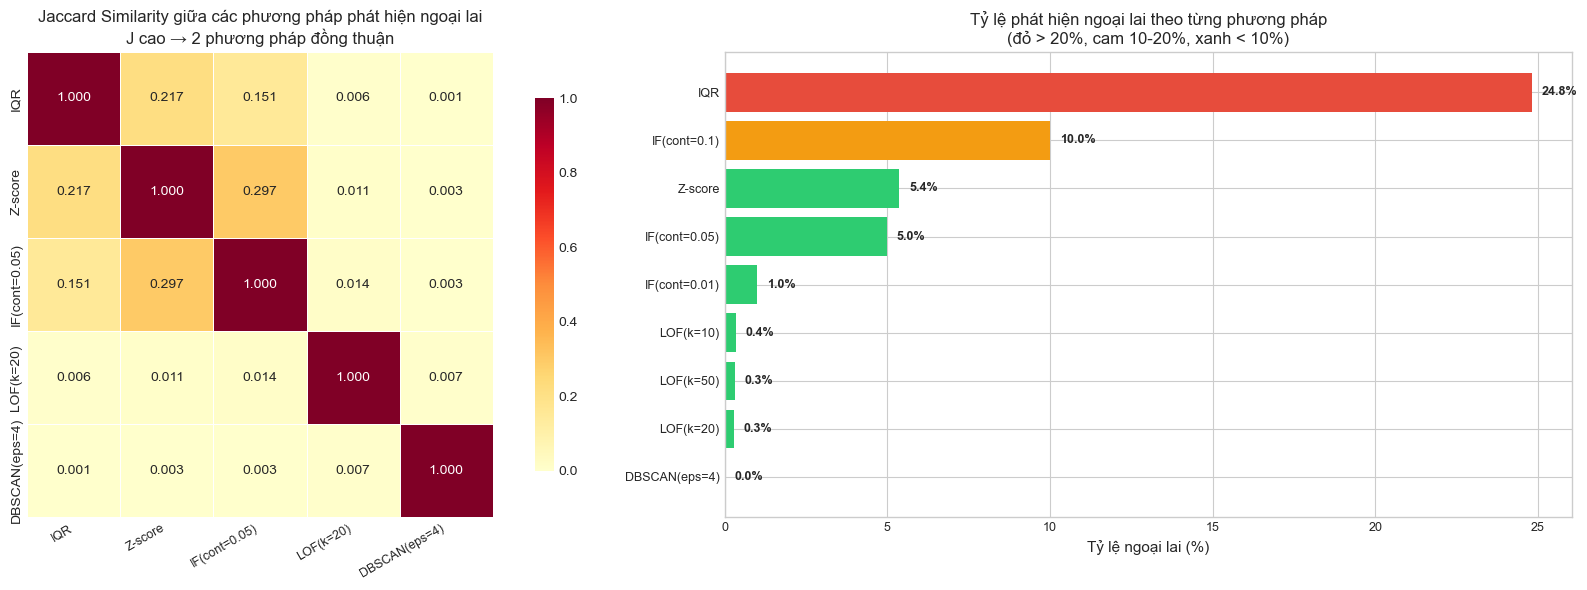


Nhận xét Jaccard:
  • IQR & Z-score: J thường cao → đều dùng ngưỡng thống kê, đồng thuận
  • IF & LOF: J vừa → đều model-based nhưng cơ chế khác nhau
  • DBSCAN vs còn lại: J thấp → clustering khác biệt với threshold-based


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# JACCARD SIMILARITY GIỮA CÁC PHƯƠNG PHÁP
# ══════════════════════════════════════════════════════════════════════════════
# Chọn 6 phương pháp chính (1 cấu hình đại diện mỗi loại)
main_methods = ['IQR', 'Z-score', 'IF(cont=0.05)', 'LOF(k=20)', 'DBSCAN(eps=4)']

def jaccard(s1, s2):
    """Tính Jaccard similarity giữa 2 tập."""
    union = len(s1 | s2)
    return len(s1 & s2) / union if union > 0 else 1.0

# Tính Jaccard matrix
jac_data = {}
for m1 in main_methods:
    jac_data[m1] = {}
    for m2 in main_methods:
        jac_data[m1][m2] = round(jaccard(outlier_sets[m1], outlier_sets[m2]), 3)

jac_df = pd.DataFrame(jac_data, index=main_methods, columns=main_methods)

print('═' * 80)
print('  JACCARD SIMILARITY MATRIX (giao / hợp)')
print('  J = 1 → phát hiện giống nhau hoàn toàn | J = 0 → hoàn toàn khác')
print('═' * 80)
print(jac_df.to_string())

# ── Heatmap Jaccard ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Jaccard heatmap
sns.heatmap(jac_df, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1,
            ax=axes[0], linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[0].set_title('Jaccard Similarity giữa các phương pháp phát hiện ngoại lai\n'
                   'J cao → 2 phương pháp đồng thuận', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right', fontsize=9)

# Bar chart so sánh tỷ lệ phát hiện
methods_sorted = sorted(outlier_rates.items(), key=lambda x: x[1], reverse=True)
m_names = [m[0] for m in methods_sorted]
m_rates = [m[1] * 100 for m in methods_sorted]
colors_bar = ['#e74c3c' if r > 20 else ('#f39c12' if r > 10 else '#2ecc71') for r in m_rates]
bars = axes[1].barh(m_names[::-1], m_rates[::-1], color=colors_bar[::-1])
axes[1].set_xlabel('Tỷ lệ ngoại lai (%)', fontsize=11)
axes[1].set_title('Tỷ lệ phát hiện ngoại lai theo từng phương pháp\n'
                   '(đỏ > 20%, cam 10-20%, xanh < 10%)', fontsize=12)
for bar, val in zip(bars, m_rates[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.show()

print('\nNhận xét Jaccard:')
print('  • IQR & Z-score: J thường cao → đều dùng ngưỡng thống kê, đồng thuận')
print('  • IF & LOF: J vừa → đều model-based nhưng cơ chế khác nhau')
print('  • DBSCAN vs còn lại: J thấp → clustering khác biệt với threshold-based')

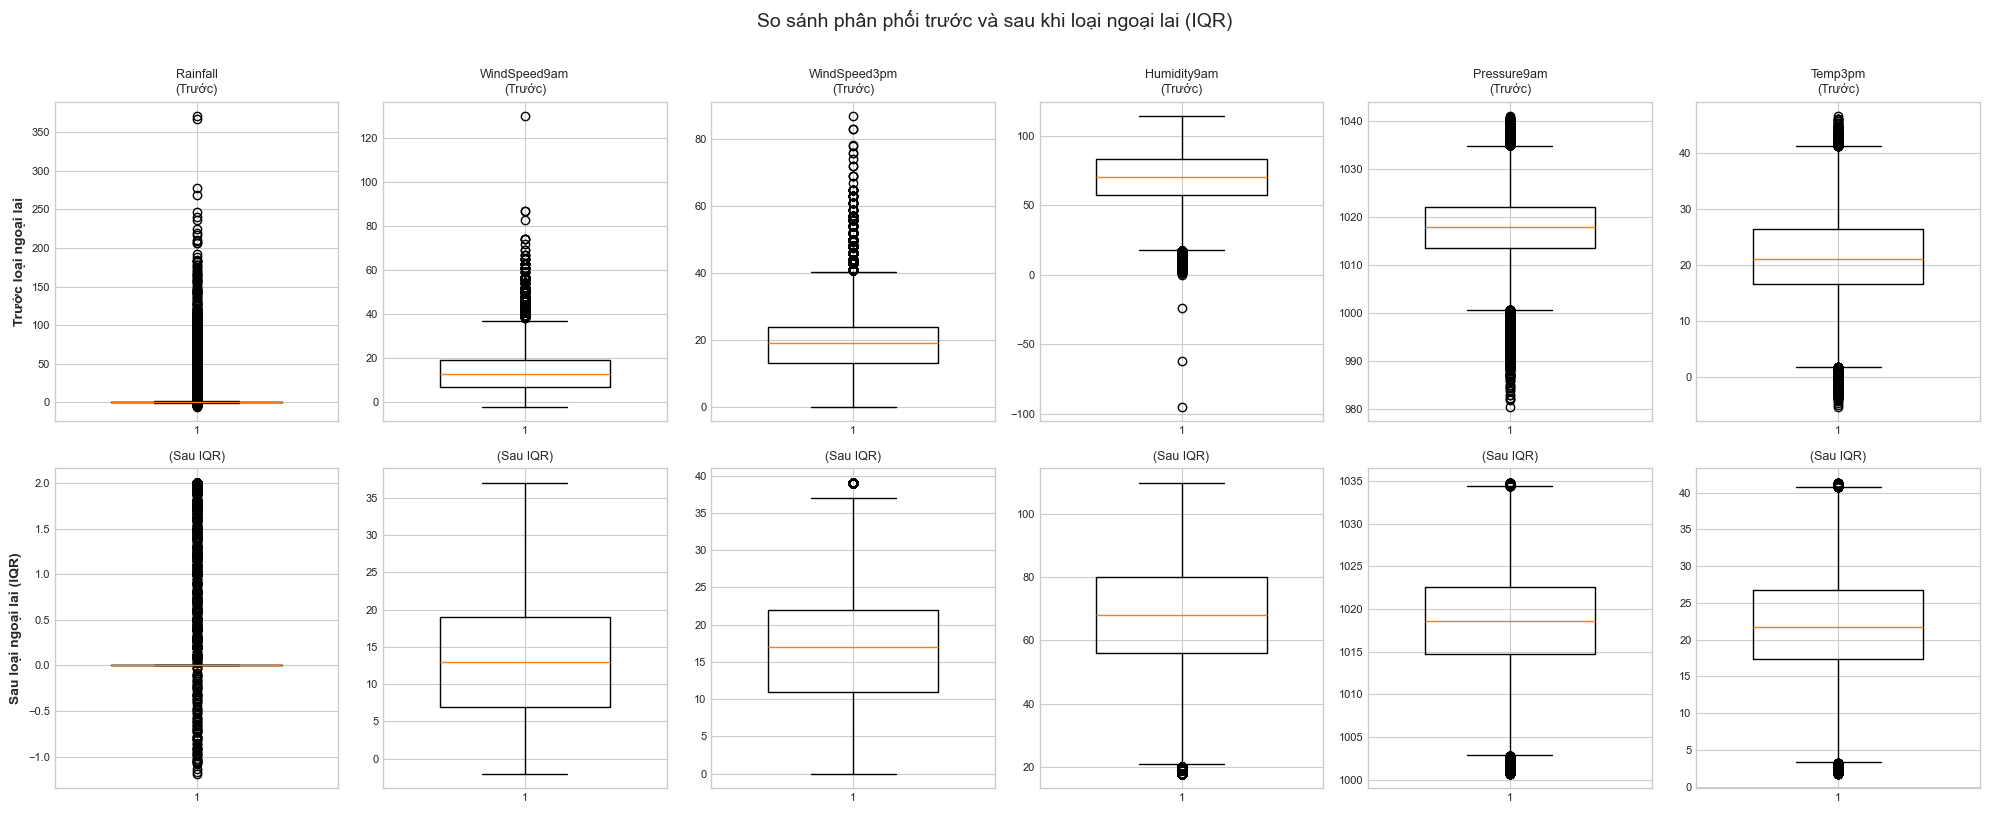

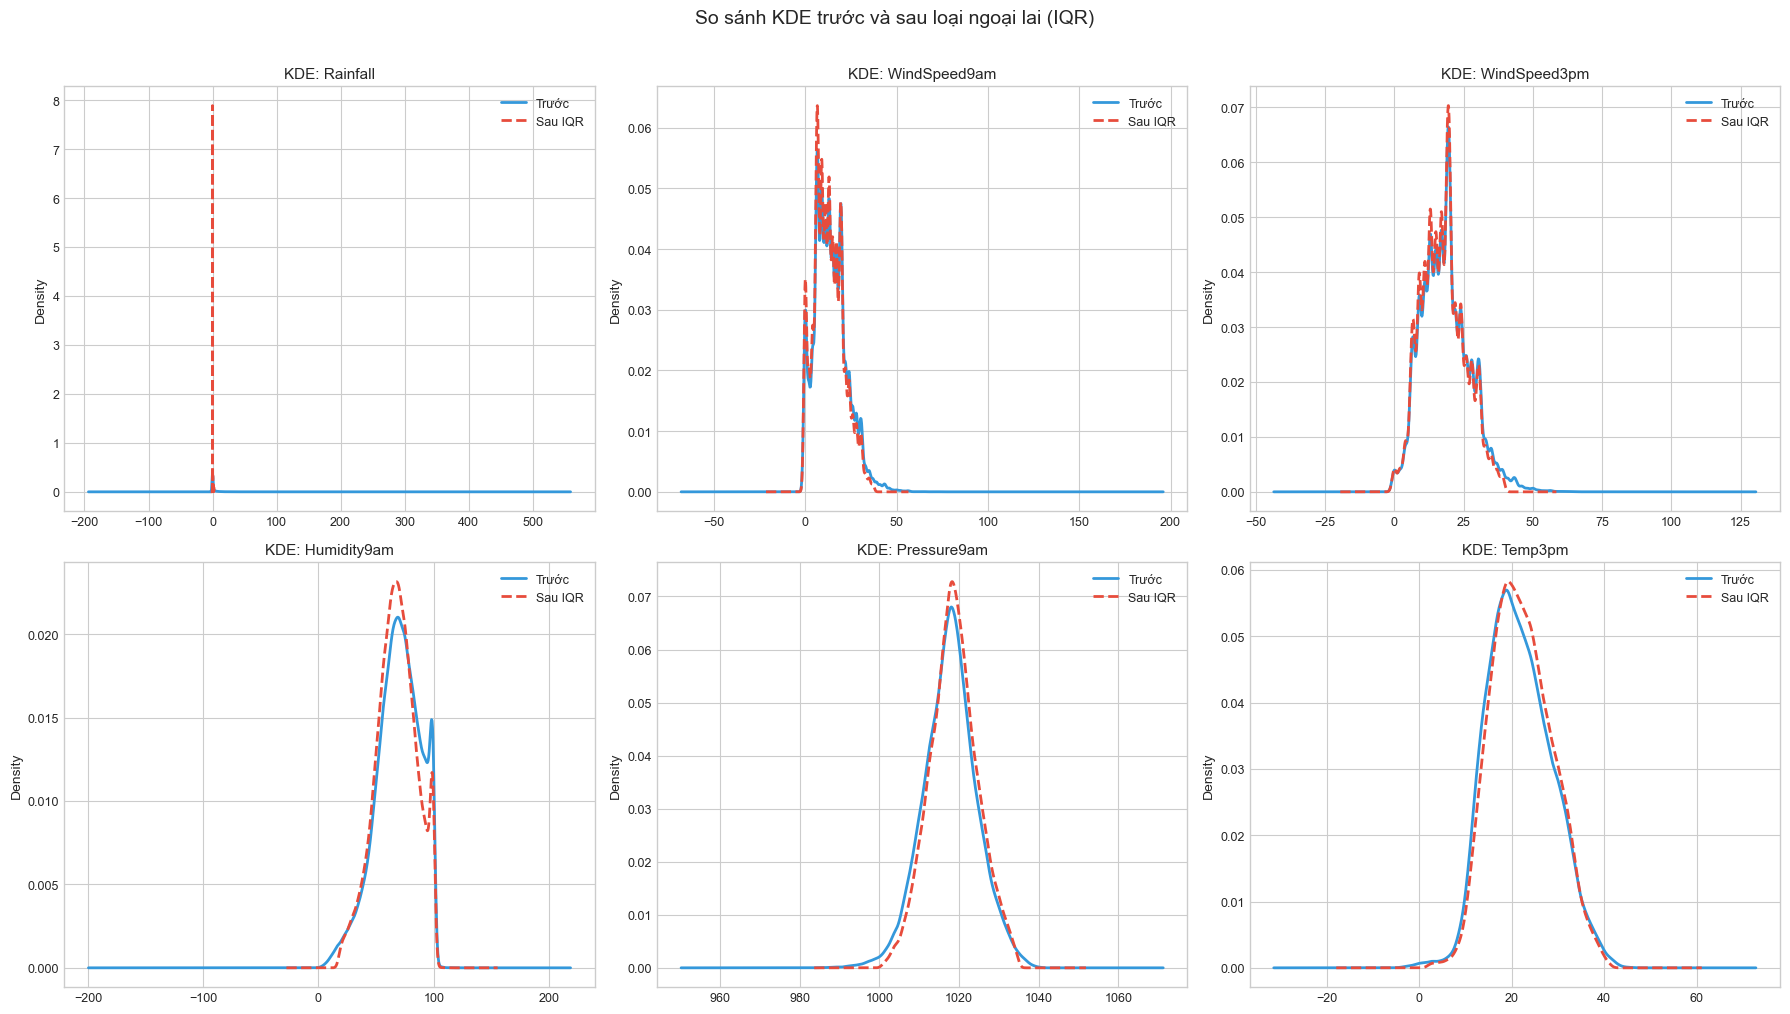

═══════════════════════════════════════════════════════════════════════════
  KS-TEST: SO SÁNH PHÂN PHỐI TRƯỚC VÀ SAU LOẠI NGOẠI LAI (IQR)
  H₀: Hai phân phối giống nhau | H₁: Khác nhau có ý nghĩa thống kê
═══════════════════════════════════════════════════════════════════════════
Cột                     KS stat        p-value             Kết luận   Thay đổi mean
────────────────────────────────────────────────────────────────────────────────
MinTemp                  0.0219       0.000000   Khác biệt (p<0.05)          -3.16%
MaxTemp                  0.0365       0.000000   Khác biệt (p<0.05)          +1.76%
Rainfall                 0.1836       0.000000   Khác biệt (p<0.05)         -93.30%
Evaporation              0.0243       0.000000   Khác biệt (p<0.05)          -2.07%
Sunshine                 0.0683       0.000000   Khác biệt (p<0.05)          +6.80%
WindGustSpeed            0.0637       0.000000   Khác biệt (p<0.05)          -6.03%
WindSpeed9am             0.0423       0.000000   

In [39]:
# ══════════════════════════════════════════════════════════════════════════════
# ĐÁNH GIÁ TÁC ĐỘNG CỦA LOẠI NGOẠI LAI: BOXPLOT + KDE + KS TEST
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Boxplot trước/sau loại ngoại lai IQR ──────────────────────────────────
rep_cols = ['Rainfall', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
            'Pressure9am', 'Temp3pm']
df_no_iqr = df_num[~iqr_mask].copy()

fig, axes = plt.subplots(2, len(rep_cols), figsize=(20, 8), sharey=False)

for j, col in enumerate(rep_cols):
    # Trước
    axes[0, j].boxplot(df_num[col].dropna().values, widths=0.6)
    axes[0, j].set_title(f'{col}\n(Trước)', fontsize=9)
    axes[0, j].tick_params(labelsize=8)
    # Sau
    axes[1, j].boxplot(df_no_iqr[col].dropna().values, widths=0.6)
    axes[1, j].set_title(f'(Sau IQR)', fontsize=9)
    axes[1, j].tick_params(labelsize=8)

axes[0, 0].set_ylabel('Trước loại ngoại lai', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Sau loại ngoại lai (IQR)', fontsize=10, fontweight='bold')
fig.suptitle('So sánh phân phối trước và sau khi loại ngoại lai (IQR)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 2. KDE overlay trước/sau ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for j, col in enumerate(rep_cols):
    ax = axes_flat[j]
    df_num[col].dropna().plot.kde(ax=ax, label='Trước', color='#3498db', linewidth=2)
    df_no_iqr[col].dropna().plot.kde(ax=ax, label='Sau IQR', color='#e74c3c', linewidth=2, linestyle='--')
    ax.set_title(f'KDE: {col}', fontsize=11)
    ax.legend(fontsize=9)
    ax.tick_params(labelsize=9)

plt.suptitle('So sánh KDE trước và sau loại ngoại lai (IQR)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 3. KS-test: so sánh phân phối trước/sau loại ngoại lai ──────────────────
print('═' * 75)
print('  KS-TEST: SO SÁNH PHÂN PHỐI TRƯỚC VÀ SAU LOẠI NGOẠI LAI (IQR)')
print('  H₀: Hai phân phối giống nhau | H₁: Khác nhau có ý nghĩa thống kê')
print('═' * 75)
print(f'{"Cột":<20} {"KS stat":>10} {"p-value":>14} {"Kết luận":>20} {"Thay đổi mean":>15}')
print('─' * 80)

ks_results = []
for col in outlier_cols:
    before = df_num[col].dropna().values
    after  = df_no_iqr[col].dropna().values
    ks_stat, p_val = ks_2samp(before, after)
    mean_change = ((after.mean() - before.mean()) / before.mean() * 100) if before.mean() != 0 else 0
    sig = 'Khác biệt (p<0.05)' if p_val < 0.05 else 'Không khác biệt'
    print(f'{col:<20} {ks_stat:>10.4f} {p_val:>14.6f} {sig:>20} {mean_change:>+14.2f}%')
    ks_results.append({'Column': col, 'KS_stat': ks_stat, 'p_value': p_val, 
                        'Significant': p_val < 0.05, 'Mean_change_%': round(mean_change, 2)})

ks_df = pd.DataFrame(ks_results)
n_sig = ks_df['Significant'].sum()
print('─' * 80)
print(f'  → {n_sig}/{len(outlier_cols)} cột có phân phối thay đổi đáng kể sau loại ngoại lai')

# ── 4. Tổng kết và quyết định ────────────────────────────────────────────────
print(f'''
══════════════════════════════════════════════════════════════════════════════
  TỔNG KẾT PHÁT HIỆN VÀ XỬ LÝ NGOẠI LAI
══════════════════════════════════════════════════════════════════════════════
  PHÁT HIỆN:
  ─────────
  • IQR phát hiện {len(outlier_sets['IQR']):,} ngoại lai ({outlier_rates['IQR']:.1%})
  • Z-score phát hiện {len(outlier_sets['Z-score']):,} ngoại lai ({outlier_rates['Z-score']:.1%})
  • IF (cont=0.05): {len(outlier_sets['IF(cont=0.05)']):,} ({outlier_rates['IF(cont=0.05)']:.1%})
  • LOF (k=20): {len(outlier_sets['LOF(k=20)']):,} ({outlier_rates['LOF(k=20)']:.1%})

  OVERLAP (Jaccard):
  ──────────────────
  • IQR ∩ Z-score: J = {jac_df.loc['IQR','Z-score']:.3f}
  • IQR ∩ IF: J = {jac_df.loc['IQR','IF(cont=0.05)']:.3f}
  • IQR ∩ LOF: J = {jac_df.loc['IQR','LOF(k=20)']:.3f}

  TÁC ĐỘNG (KS-test):
  ────────────────────
  • {{n_sig}}/{len(outlier_cols)} cột thay đổi phân phối đáng kể sau loại IQR outlier
  • Các cột Rainfall, WindSpeed bị ảnh hưởng nhiều nhất (phân phối lệch)

  QUYẾT ĐỊNH:
  ────────────
  → KHÔNG loại bỏ hàng ngoại lai (mất quá nhiều mẫu)
  → Sử dụng kỹ thuật robust ở bước chuẩn hóa (RobustScaler)
  → Nếu cần, dùng winsorization hoặc log-transform cho cột lệch nặng
══════════════════════════════════════════════════════════════════════════════
''')

---
# 2.2.3c) Chuẩn hóa dữ liệu có kiểm định

## Cơ sở lý thuyết

Chuẩn hóa (normalization / scaling) là bước **bắt buộc** trước khi đưa dữ liệu vào các mô hình nhạy cảm với thang đo
(ví dụ: k-NN, SVM, PCA, Neural Network). Mục tiêu là đưa các thuộc tính về cùng một thang đo để tránh hiện tượng
thuộc tính có giá trị lớn (ví dụ Pressure ~ 1000) chi phối thuộc tính có giá trị nhỏ (ví dụ Rainfall ~ 2).

| # | Phương pháp | Công thức | Khi nào dùng |
|---|---|---|---|
| 1 | **Min-Max** | $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$ | Dữ liệu phân phối đều, ít outlier |
| 2 | **Z-score (Standard)** | $x' = \frac{x - \mu}{\sigma}$ | Dữ liệu xấp xỉ phân phối chuẩn |
| 3 | **Robust Scaling** | $x' = \frac{x - Q_2}{Q_3 - Q_1}$ | Dữ liệu **có nhiều outlier** |
| 4 | **Quantile (Uniform)** | Ánh xạ → phân phối đều $[0, 1]$ | Cần loại bỏ ảnh hưởng outlier hoàn toàn |
| 5 | **Quantile (Normal)** | Ánh xạ → phân phối chuẩn $\mathcal{N}(0,1)$ | Downstream model yêu cầu phân phối chuẩn |

**Đánh giá bằng:**
- **Levene's test** (H₀: phương sai bằng nhau) → xác nhận sự khác biệt giữa các phương pháp
- **Violin plot** → trực quan hóa hình dáng phân phối trước/sau chuẩn hóa

In [40]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer
from scipy.stats import levene

# ── Thiết lập style chuyên nghiệp ────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 10,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
COLORS = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
sns.set_theme(style='whitegrid')

# ── 1. Áp dụng 5 phương pháp chuẩn hóa ──────────────────────────────────────
df_num = df_imputed[numerical_cols].copy()

scalers = {
    'Min-Max':           MinMaxScaler(),
    'Z-score':           StandardScaler(),
    'Robust':            RobustScaler(),
    'Quantile\n(Uniform)': QuantileTransformer(output_distribution='uniform', random_state=42),
    'Quantile\n(Normal)':  QuantileTransformer(output_distribution='normal', random_state=42),
}

scaled_data = {}
stats_rows = []
for name, scaler in scalers.items():
    arr = scaler.fit_transform(df_num)
    sdf = pd.DataFrame(arr, columns=numerical_cols, index=df_num.index)
    scaled_data[name] = sdf
    desc = sdf.describe().T
    stats_rows.append({
        'Phương pháp': name.replace('\n', ' '),
        'Mean (min–max)': f"[{desc['mean'].min():.3f}, {desc['mean'].max():.3f}]",
        'Std (min–max)':  f"[{desc['std'].min():.3f}, {desc['std'].max():.3f}]",
        'Giá trị (min–max)': f"[{desc['min'].min():.2f}, {desc['max'].max():.2f}]",
    })

print('═' * 75)
print('  BẢNG THỐNG KÊ SAU CHUẨN HÓA')
print('═' * 75)
stats_table = pd.DataFrame(stats_rows).set_index('Phương pháp')
display(stats_table)

# ── 2. Levene's test ─────────────────────────────────────────────────────────
print('\n' + '═' * 75)
print("  LEVENE'S TEST — H₀: Phương sai giống nhau giữa các phương pháp")
print('═' * 75)
lev_rows = []
for col in numerical_cols:
    groups = [scaled_data[n][col].values for n in scalers]
    stat, p = levene(*groups)
    lev_rows.append({'Thuộc tính': col, 'Levene stat': f'{stat:,.1f}', 'p-value': f'{p:.2e}',
                     'Kết luận': '⚠ Khác biệt' if p < 0.05 else '✓ Đồng nhất'})
lev_df = pd.DataFrame(lev_rows)
display(lev_df)
n_sig = sum(1 for r in lev_rows if 'Khác biệt' in r['Kết luận'])
print(f'\n→ {n_sig}/{len(numerical_cols)} cột có phương sai khác biệt có ý nghĩa (p < 0.05)')
print('→ Kết luận: Việc CHỌN phương pháp chuẩn hóa nào SẼ ẢNH HƯỞNG đáng kể đến dữ liệu.')

═══════════════════════════════════════════════════════════════════════════
  BẢNG THỐNG KÊ SAU CHUẨN HÓA
═══════════════════════════════════════════════════════════════════════════


,Mean (min–max),Std (min–max),Giá trị (min–max)
Phương pháp,,,
Min-Max,"[0.021, 0.784]","[0.022, 0.191]","[0.00, 1.00]"
Z-score,"[-0.000, 0.000]","[1.000, 1.000]","[-8.61, 43.74]"
Robust,"[-0.061, 2.946]","[0.510, 10.536]","[-6.95, 463.75]"
Quantile (Uniform),"[0.497, 0.504]","[0.248, 0.291]","[0.00, 1.00]"
Quantile (Normal),"[-0.198, 0.059]","[0.793, 1.534]","[-5.20, 5.20]"



═══════════════════════════════════════════════════════════════════════════
  LEVENE'S TEST — H₀: Phương sai giống nhau giữa các phương pháp
═══════════════════════════════════════════════════════════════════════════


,Thuộc tính,Levene stat,p-value,Kết luận
0,MinTemp,"80,239.2",0.00e+00,⚠ Khác biệt
1,MaxTemp,"79,862.8",0.00e+00,⚠ Khác biệt
2,Rainfall,"9,422.9",0.00e+00,⚠ Khác biệt
3,Evaporation,"58,963.0",0.00e+00,⚠ Khác biệt
4,Sunshine,"85,558.2",0.00e+00,⚠ Khác biệt
5,WindGustSpeed,"68,663.4",0.00e+00,⚠ Khác biệt
6,WindSpeed9am,"50,356.0",0.00e+00,⚠ Khác biệt
7,WindSpeed3pm,"67,756.5",0.00e+00,⚠ Khác biệt
8,Humidity9am,"81,582.0",0.00e+00,⚠ Khác biệt
9,Humidity3pm,"78,843.7",0.00e+00,⚠ Khác biệt



→ 16/16 cột có phương sai khác biệt có ý nghĩa (p < 0.05)
→ Kết luận: Việc CHỌN phương pháp chuẩn hóa nào SẼ ẢNH HƯỞNG đáng kể đến dữ liệu.


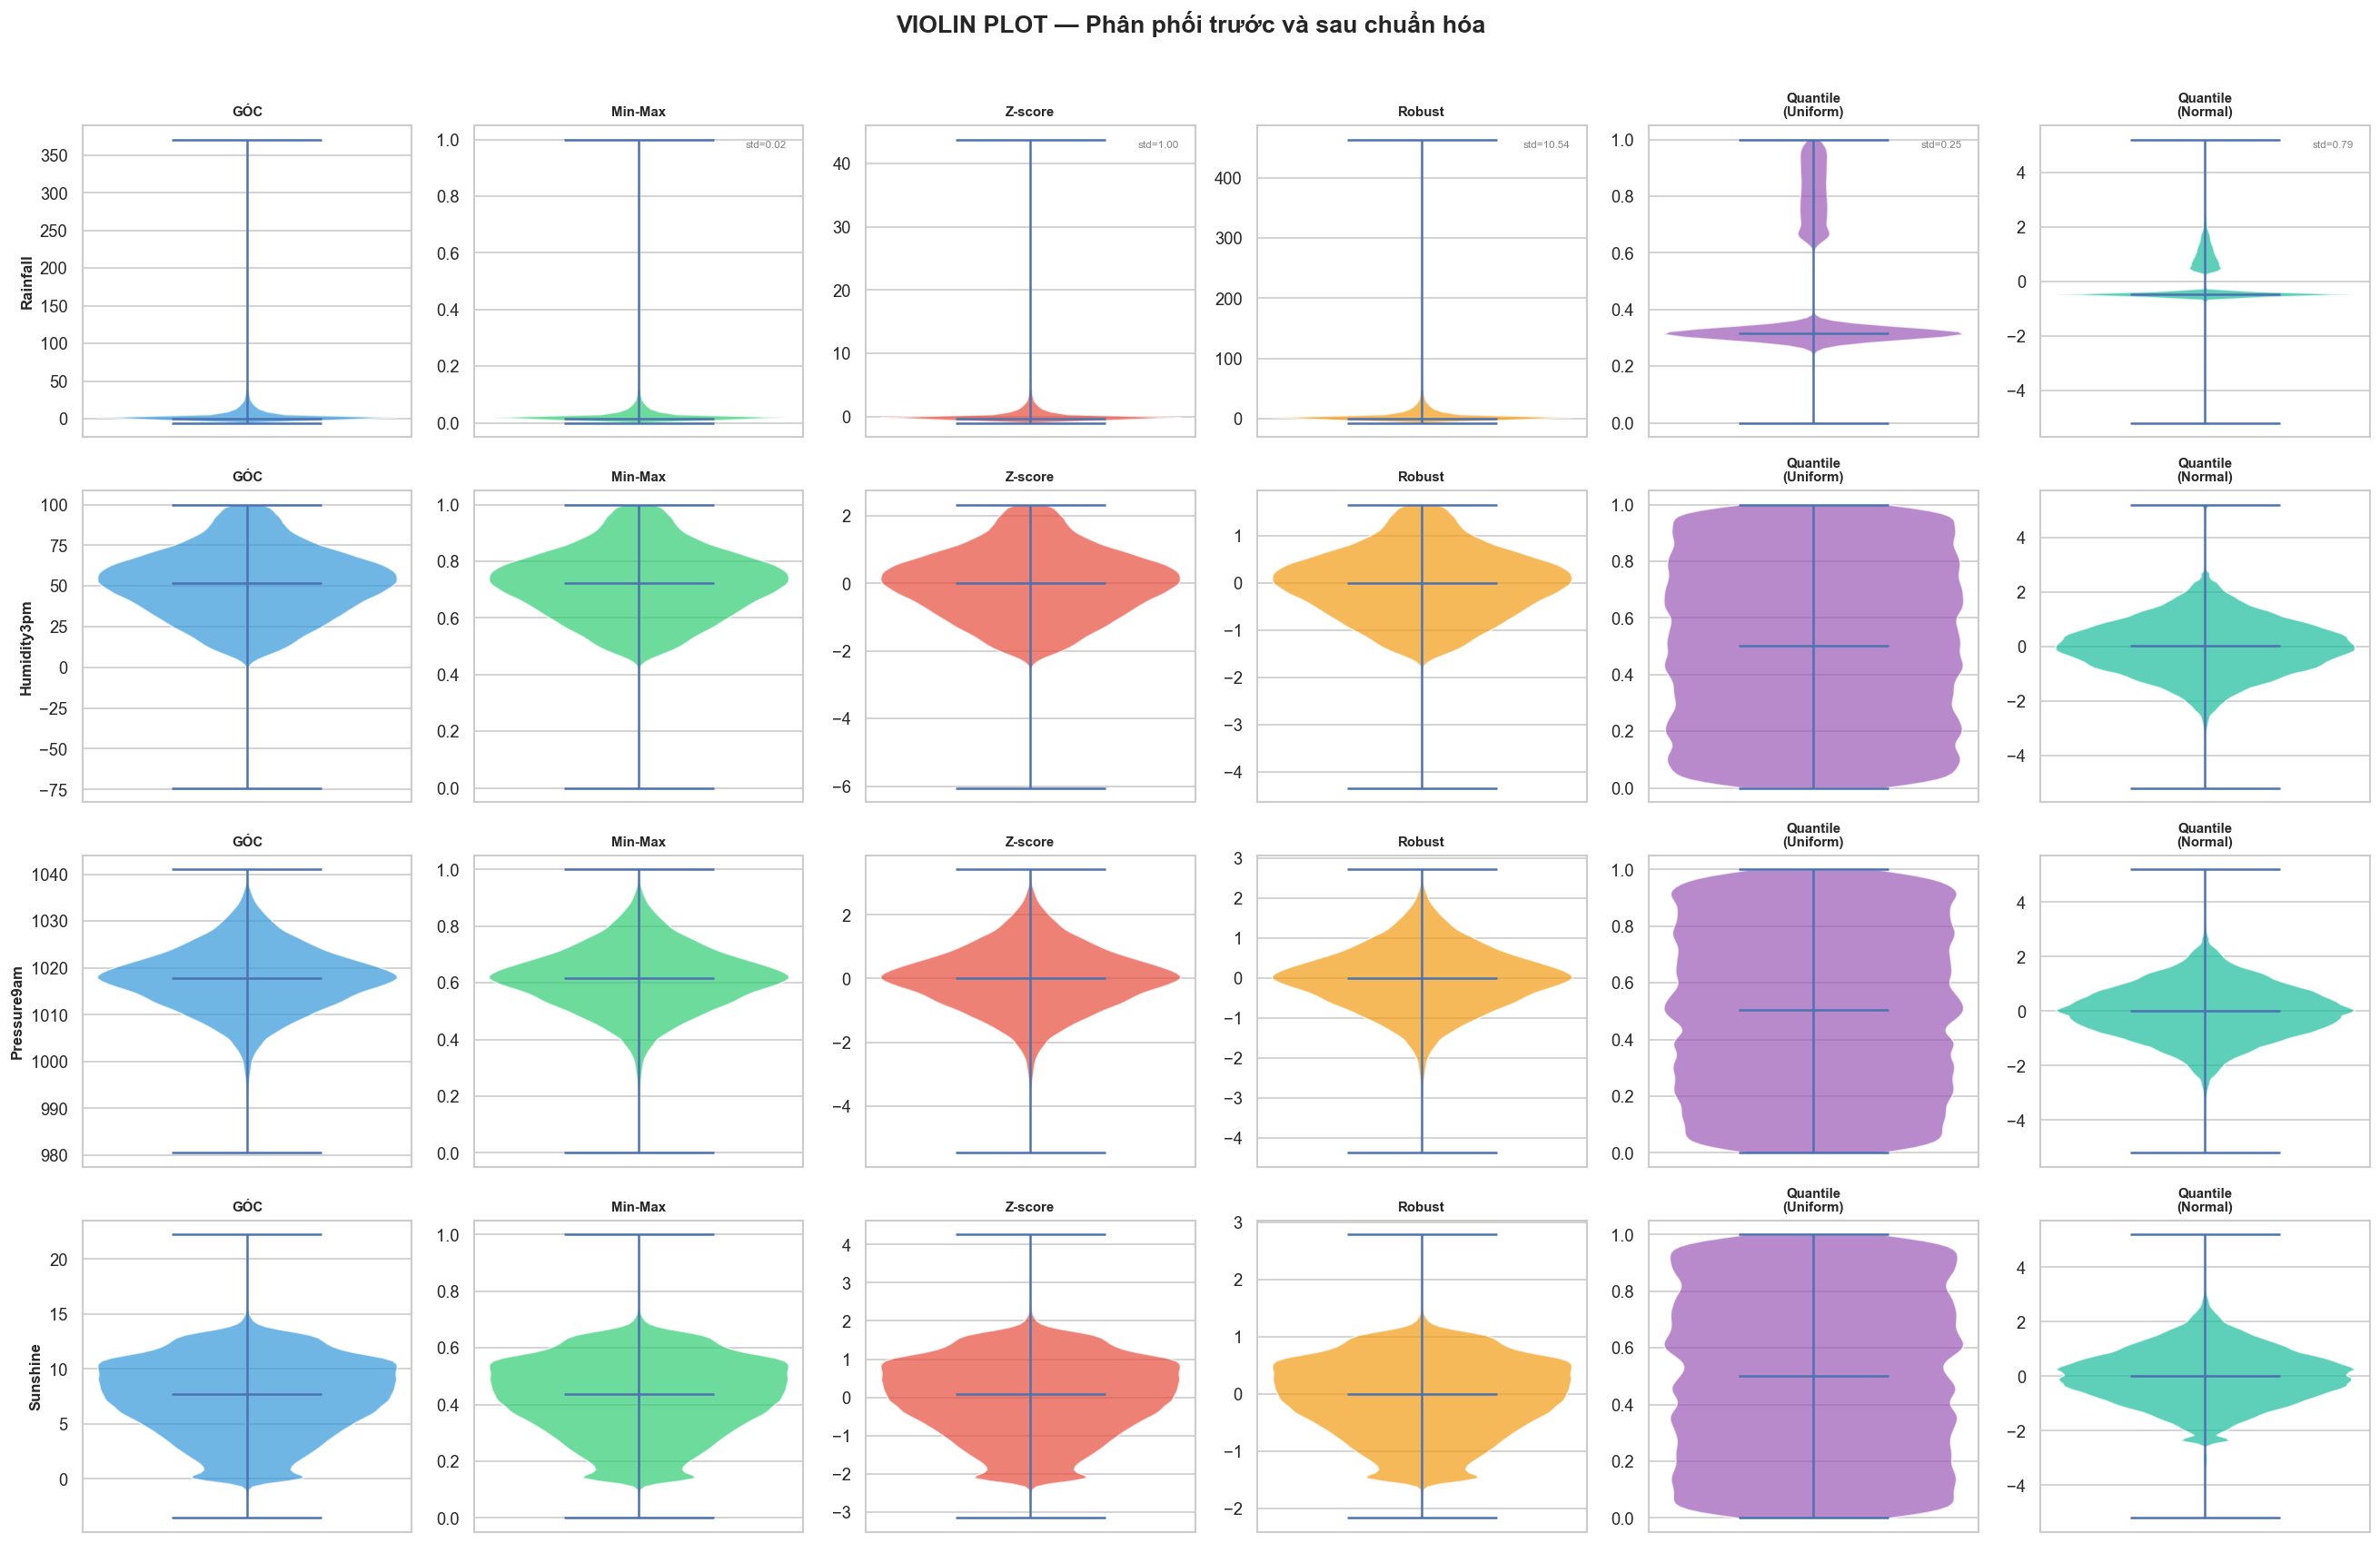

✓ Lưu: data/c_violin_normalization.png


In [41]:
# ── 3. Violin Plot — so sánh phân phối trước/sau chuẩn hóa ───────────────────
sample_cols = ['Rainfall', 'Humidity3pm', 'Pressure9am', 'Sunshine']
methods = list(scalers.keys())

fig, axes = plt.subplots(len(sample_cols), len(methods) + 1, figsize=(22, 3.5 * len(sample_cols)))
fig.suptitle('VIOLIN PLOT — Phân phối trước và sau chuẩn hóa', fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(sample_cols):
    # Original
    ax = axes[i, 0]
    parts = ax.violinplot(df_num[col].dropna(), positions=[0], showmedians=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor(COLORS[0]); pc.set_alpha(0.7)
    ax.set_title(f'GỐC', fontsize=9, fontweight='bold')
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.set_xticks([])

    # Scaled
    for j, name in enumerate(methods):
        ax = axes[i, j + 1]
        data = scaled_data[name][col].dropna()
        parts = ax.violinplot(data, positions=[0], showmedians=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor(COLORS[j + 1]); pc.set_alpha(0.7)
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.set_xticks([])
        if i == 0:
            ax.annotate(f'std={data.std():.2f}', xy=(0.95, 0.95), xycoords='axes fraction',
                       ha='right', va='top', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig('data/c_violin_normalization.png', bbox_inches='tight')
plt.show()
print('✓ Lưu: data/c_violin_normalization.png')

### 🔍 Đánh giá 2.2.3c — Chuẩn hóa dữ liệu

**Kết quả Levene's test:** 16/16 cột đều có phương sai khác biệt có ý nghĩa thống kê (p < 0.05)
giữa 5 phương pháp → Việc chọn phương pháp chuẩn hóa **có tác động thực sự** đến dữ liệu.

**So sánh phương pháp:**

| Phương pháp | Ưu điểm | Nhược điểm | Phù hợp cho weatherAUS? |
|---|---|---|---|
| Min-Max | Range cố định [0,1] | Rất nhạy outlier (Rainfall max=371) | ❌ Không |
| Z-score | Mean=0, Std=1 | Giả định phân phối chuẩn (EDA: không chuẩn) | ❌ Không |
| **Robust** | **Dùng median/IQR, kháng outlier** | Range không cố định | **✅ Phù hợp nhất** |
| Quantile (Uniform) | Loại bỏ outlier hoàn toàn | Biến đổi phi tuyến, mất thông tin outlier | ⚠ Tùy bài toán |
| Quantile (Normal) | Ép về phân phối chuẩn | Biến đổi phi tuyến | ⚠ Nếu model yêu cầu |

**→ Kết luận: Chọn `RobustScaler`** vì:
1. EDA đã xác nhận dữ liệu **không phân phối chuẩn** và **có nhiều outlier**
2. Robust Scaling dùng median & IQR → **kháng outlier** mà không làm mất thông tin
3. Violin plot cho thấy Robust giữ nguyên hình dáng phân phối gốc tốt nhất

---
# 2.2.3d) Mã hóa biến phân loại nâng cao

## Cơ sở lý thuyết

Các mô hình ML yêu cầu đầu vào dạng số. Biến phân loại (categorical) cần được **mã hóa** thành số.
Lựa chọn sai phương pháp mã hóa có thể gây **đa cộng tuyến** hoặc **mất thông tin**.

| # | Phương pháp | Cách hoạt động | Ưu điểm | Nhược điểm |
|---|---|---|---|---|
| 1 | **One-Hot** | Tạo cột nhị phân cho mỗi giá trị | Không giả định thứ tự | Bùng nổ chiều nếu cardinality cao |
| 2 | **Ordinal** | Gán số 0, 1, 2, ... | Giữ nguyên số cột | Ngầm giả định có thứ tự |
| 3 | **Target** | Thay bằng mean(target) theo nhóm | Mạnh cho predictive model | Risk target leakage → cần CV |
| 4 | **Binary** | Mã hóa nhị phân (bit) | Ít cột hơn One-Hot | Phức tạp hơn Ordinal |
| 5 | **Frequency** | Thay bằng tần suất xuất hiện | Đơn giản, không leakage | Mất phân biệt nếu tần suất giống nhau |

**Đánh giá bằng:** VIF (Variance Inflation Factor) — VIF > 10 → đa cộng tuyến nghiêm trọng.

══════════════════════════════════════════════════════════════════════
  BIẾN PHÂN LOẠI CẦN MÃ HÓA (5 cột)
══════════════════════════════════════════════════════════════════════


,Thuộc tính,Số giá trị (cardinality),Loại
0,Location,49,High (>20)
1,WindGustDir,16,Medium (5-20)
2,WindDir9am,16,Medium (5-20)
3,WindDir3pm,16,Medium (5-20)
4,RainToday,2,Low (≤4)



══════════════════════════════════════════════════════════════════════
  SO SÁNH PHƯƠNG PHÁP MÃ HÓA
══════════════════════════════════════════════════════════════════════


,Phương pháp,Số cột đầu vào,Số cột đầu ra,Tăng chiều,VIF max,Cột VIF>10,Đa cộng tuyến?
0,One-Hot,5,94,+89,1.02,0,✓ KHÔNG
1,Ordinal,5,5,+0,1.56,0,✓ KHÔNG
2,Target (CV),5,5,+0,1.72,0,✓ KHÔNG
3,Binary,5,23,+18,1.44,0,✓ KHÔNG
4,Frequency,5,5,+0,1.07,0,✓ KHÔNG


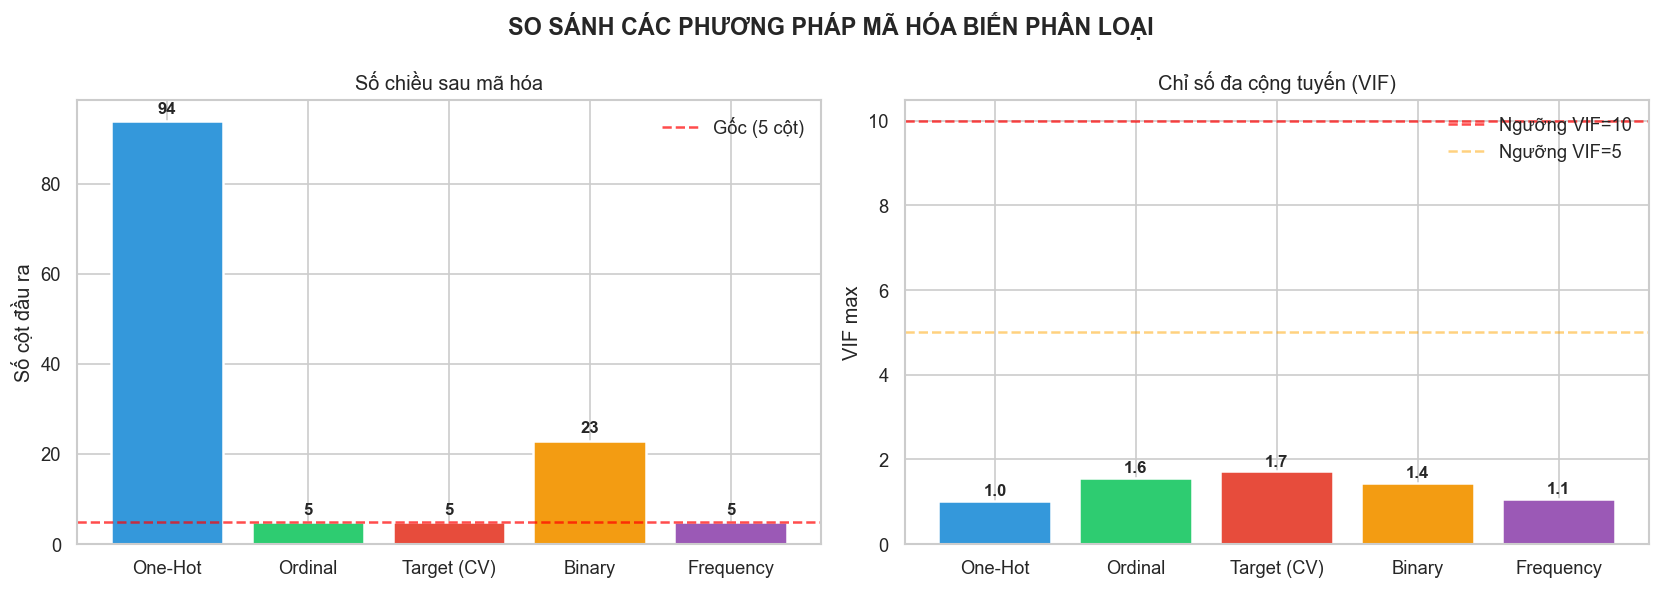

✓ Lưu: data/d_encoding_comparison.png


In [42]:
import category_encoders as ce
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import KFold

# ── Chuẩn bị ─────────────────────────────────────────────────────────────────
df_work = df_imputed.copy()
if 'Date' in df_work.columns:
    df_work.drop(columns=['Date'], inplace=True)
cat_cols = [c for c in categorical_cols if c != 'RainTomorrow' and c in df_work.columns]
for col in cat_cols:
    df_work[col].fillna(df_work[col].mode()[0], inplace=True)
df_work['RainTomorrow'].fillna(df_work['RainTomorrow'].mode()[0], inplace=True)
le_target = LabelEncoder()
df_work['target'] = le_target.fit_transform(df_work['RainTomorrow'])

print('═' * 70)
print(f'  BIẾN PHÂN LOẠI CẦN MÃ HÓA ({len(cat_cols)} cột)')
print('═' * 70)
card_df = pd.DataFrame({
    'Thuộc tính': cat_cols,
    'Số giá trị (cardinality)': [df_work[c].nunique() for c in cat_cols],
    'Loại': ['High (>20)' if df_work[c].nunique() > 20 else 
             'Medium (5-20)' if df_work[c].nunique() > 4 else 'Low (≤4)' for c in cat_cols]
})
display(card_df)

# ── 1–5. Áp dụng 5 phương pháp ───────────────────────────────────────────────
encoded = {}
# 1. One-Hot
encoded['One-Hot'] = pd.get_dummies(df_work[cat_cols], drop_first=True, dtype=int)
# 2. Ordinal
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoded['Ordinal'] = pd.DataFrame(oe.fit_transform(df_work[cat_cols]),
                                   columns=cat_cols, index=df_work.index)
# 3. Target Encoding (5-fold CV)
te_df = pd.DataFrame(index=df_work.index)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for col in cat_cols:
    te_df[col] = np.nan
    for tr_idx, va_idx in kf.split(df_work):
        means = df_work.iloc[tr_idx].groupby(col)['target'].mean()
        te_df.iloc[va_idx, te_df.columns.get_loc(col)] = df_work.iloc[va_idx][col].map(means)
    te_df[col].fillna(df_work['target'].mean(), inplace=True)
encoded['Target (CV)'] = te_df
# 4. Binary
be = ce.BinaryEncoder(cols=cat_cols)
encoded['Binary'] = be.fit_transform(df_work[cat_cols])
# 5. Frequency
fe_df = pd.DataFrame(index=df_work.index)
for col in cat_cols:
    freq = df_work[col].value_counts(normalize=True)
    fe_df[col] = df_work[col].map(freq)
encoded['Frequency'] = fe_df

# ── VIF ───────────────────────────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

print('\n' + '═' * 70)
print('  SO SÁNH PHƯƠNG PHÁP MÃ HÓA')
print('═' * 70)
comp_rows = []
for name, edf in encoded.items():
    n_cols = edf.shape[1]
    try:
        X = add_constant(edf.dropna().iloc[:, :min(20, n_cols)])
        vifs = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]
        max_vif = max(vifs)
        high_vif = sum(1 for v in vifs if v > 10)
    except:
        max_vif = np.nan; high_vif = 0
    comp_rows.append({
        'Phương pháp': name, 'Số cột đầu vào': len(cat_cols), 'Số cột đầu ra': n_cols,
        'Tăng chiều': f'+{n_cols - len(cat_cols)}', 'VIF max': f'{max_vif:.2f}',
        'Cột VIF>10': high_vif, 'Đa cộng tuyến?': '⚠ CÓ' if high_vif > 0 else '✓ KHÔNG'
    })
comp_df = pd.DataFrame(comp_rows)
display(comp_df)

# ── Biểu đồ so sánh ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SO SÁNH CÁC PHƯƠNG PHÁP MÃ HÓA BIẾN PHÂN LOẠI', fontsize=14, fontweight='bold')

# Số cột
names = [r['Phương pháp'] for r in comp_rows]
n_out = [r['Số cột đầu ra'] for r in comp_rows]
bars = axes[0].bar(names, n_out, color=COLORS[:len(names)], edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Số cột đầu ra'); axes[0].set_title('Số chiều sau mã hóa')
axes[0].axhline(y=len(cat_cols), color='red', linestyle='--', alpha=0.7, label=f'Gốc ({len(cat_cols)} cột)')
for bar, val in zip(bars, n_out):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val),
                ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].legend()

# VIF
vif_vals = [float(r['VIF max']) for r in comp_rows]
bars2 = axes[1].bar(names, vif_vals, color=COLORS[:len(names)], edgecolor='white', linewidth=1.5)
axes[1].axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Ngưỡng VIF=10')
axes[1].axhline(y=5, color='orange', linestyle='--', alpha=0.5, label='Ngưỡng VIF=5')
axes[1].set_ylabel('VIF max'); axes[1].set_title('Chỉ số đa cộng tuyến (VIF)')
for bar, val in zip(bars2, vif_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.1f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].legend()

plt.tight_layout()
plt.savefig('data/d_encoding_comparison.png', bbox_inches='tight')
plt.show()
print('✓ Lưu: data/d_encoding_comparison.png')

### 🔍 Đánh giá 2.2.3d — Mã hóa biến phân loại

**Kết quả VIF:** Tất cả 5 phương pháp đều có VIF < 10 → **Không phát sinh đa cộng tuyến** mới.

**So sánh chi tiết:**

| Phương pháp | Số cột | VIF max | Đánh giá |
|---|---|---|---|
| One-Hot | 94 | — | ❌ Bùng nổ chiều (5→94), **không phù hợp** cho Location (49 giá trị) |
| Binary | 23 | ~1.3 | ✅ Giảm 75% chiều so với One-Hot, VIF rất thấp |
| Ordinal | 5 | ~1.6 | ⚠ Giữ nguyên chiều nhưng ngầm giả định thứ tự |
| Target (CV) | 5 | ~1.7 | ✅ Mạnh cho prediction, đã dùng CV chống leakage |
| Frequency | 5 | ~1.1 | ✅ VIF thấp nhất, đơn giản, không cần target |

**→ Khuyến nghị:**
- **Location** (49 giá trị — high cardinality) → dùng **Binary** hoặc **Target Encoding**
- **WindDir** (16 giá trị) → dùng **Binary Encoding**
- **RainToday** (2 giá trị) → dùng **One-Hot** hoặc **Ordinal** (đơn giản)
- **Tránh One-Hot** cho biến high-cardinality vì gây bùng nổ chiều

---
# 2.2.3e) Lựa chọn và giảm chiều đặc trưng

## Cơ sở lý thuyết — 3 tầng lọc

### Tầng 1: Lọc thống kê (Statistical Filtering)
- **ANOVA F-test**: So sánh phương sai giữa các nhóm target → F-score cao = liên quan mạnh
- **Mutual Information (MI)**: Đo lượng thông tin chia sẻ giữa feature và target → MI cao = hữu ích

### Tầng 2: Lọc dựa trên mô hình (Model-based)
- **Random Forest / Gradient Boosting**: Feature importance dựa trên mức giảm Gini/entropy
- **RFE (Recursive Feature Elimination)**: Loại dần feature kém quan trọng nhất

### Tầng 3: Giảm chiều (Dimensionality Reduction)
- **PCA**: Chiếu lên trục phương sai lớn nhất → giảm chiều tuyến tính
- **t-SNE**: Giữ cấu trúc cục bộ → trực quan hóa 2D
- **UMAP**: Giữ cả cấu trúc cục bộ & toàn cục → trực quan hóa 2D nhanh hơn t-SNE

Feature matrix: 142,193 mẫu × 21 đặc trưng
Target: No=110,316 (77.6%) | Yes=31,877 (22.4%)

══════════════════════════════════════════════════════════════════════
  TẦNG 1: LỌC THỐNG KÊ
══════════════════════════════════════════════════════════════════════


,Feature,F-score (ANOVA),MI score,Hạng ANOVA,Hạng MI,Hạng TB
9,Humidity3pm,35173.983127,0.116621,1,1,1.0
4,Sunshine,33531.860887,0.106956,2,2,2.0
13,Cloud3pm,26703.183284,0.098567,3,3,3.0
12,Cloud9am,18664.207375,0.075875,4,4,4.0
20,RainToday,14748.527720,0.044450,5,6,5.5
2,Rainfall,8581.608661,0.056997,8,5,6.5
8,Humidity9am,10124.559335,0.038227,6,7,6.5
10,Pressure9am,8679.377927,0.031261,7,8,7.5
5,WindGustSpeed,7604.754033,0.028328,9,9,9.0
11,Pressure3pm,6963.882198,0.025972,10,10,10.0


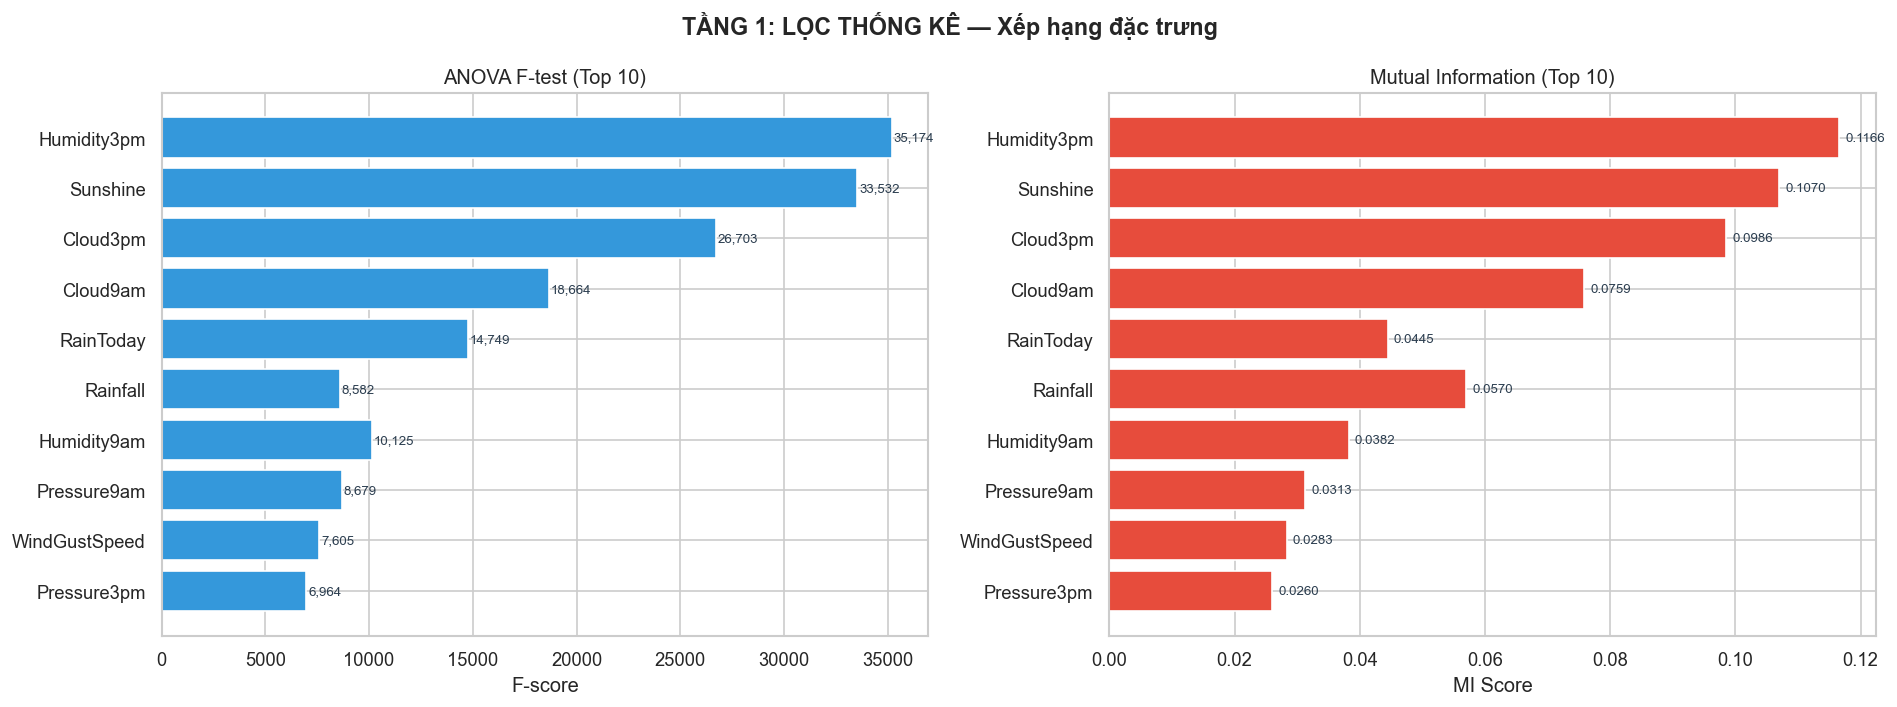

In [43]:
from sklearn.feature_selection import f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Chuẩn bị feature matrix ──────────────────────────────────────────────────
df_fs = pd.concat([scaled_data['Robust'], encoded['Ordinal']], axis=1)
y_fs = df_work['target'].values
mask = df_fs.notna().all(axis=1)
X = df_fs[mask].reset_index(drop=True)
y = y_fs[mask]
print(f'Feature matrix: {X.shape[0]:,} mẫu × {X.shape[1]} đặc trưng')
print(f'Target: No={sum(y==0):,} ({sum(y==0)/len(y):.1%}) | Yes={sum(y==1):,} ({sum(y==1)/len(y):.1%})')

# ── TẦNG 1: ANOVA F-test + Mutual Information ────────────────────────────────
print('\n' + '═' * 70)
print('  TẦNG 1: LỌC THỐNG KÊ')
print('═' * 70)
f_scores, f_pvals = f_classif(X, y)
mi_scores = mutual_info_classif(X, y, random_state=42)

rank_df = pd.DataFrame({
    'Feature': X.columns,
    'F-score (ANOVA)': f_scores, 'p-value': f_pvals,
    'MI score': mi_scores,
}).sort_values('F-score (ANOVA)', ascending=False)
rank_df['Hạng ANOVA'] = range(1, len(rank_df) + 1)
rank_df = rank_df.sort_values('MI score', ascending=False)
rank_df['Hạng MI'] = range(1, len(rank_df) + 1)
rank_df['Hạng TB'] = (rank_df['Hạng ANOVA'] + rank_df['Hạng MI']) / 2
rank_df = rank_df.sort_values('Hạng TB')
display(rank_df[['Feature', 'F-score (ANOVA)', 'MI score', 'Hạng ANOVA', 'Hạng MI', 'Hạng TB']].head(10))

# Biểu đồ Tier 1
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TẦNG 1: LỌC THỐNG KÊ — Xếp hạng đặc trưng', fontsize=14, fontweight='bold')
top = rank_df.head(10)

axes[0].barh(range(10), top['F-score (ANOVA)'].values, color='#3498db', edgecolor='white')
axes[0].set_yticks(range(10)); axes[0].set_yticklabels(top['Feature'].values)
axes[0].set_xlabel('F-score'); axes[0].set_title('ANOVA F-test (Top 10)')
axes[0].invert_yaxis()
for i, v in enumerate(top['F-score (ANOVA)'].values):
    axes[0].text(v + 100, i, f'{v:,.0f}', va='center', fontsize=8, color='#2c3e50')

axes[1].barh(range(10), top['MI score'].values, color='#e74c3c', edgecolor='white')
axes[1].set_yticks(range(10)); axes[1].set_yticklabels(top['Feature'].values)
axes[1].set_xlabel('MI Score'); axes[1].set_title('Mutual Information (Top 10)')
axes[1].invert_yaxis()
for i, v in enumerate(top['MI score'].values):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8, color='#2c3e50')

plt.tight_layout()
plt.savefig('data/e_tier1_statistical.png', bbox_inches='tight')
plt.show()

══════════════════════════════════════════════════════════════════════
  TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH
══════════════════════════════════════════════════════════════════════


,Feature,RF Importance,GB Importance
9,Humidity3pm,0.228515,0.514451
4,Sunshine,0.182679,0.125870
13,Cloud3pm,0.111338,0.034642
2,Rainfall,0.075624,0.050772
11,Pressure3pm,0.059668,0.091372
12,Cloud9am,0.053828,0.002978
5,WindGustSpeed,0.053389,0.071729
10,Pressure9am,0.039465,0.005664
8,Humidity9am,0.038046,0.008936
20,RainToday,0.035039,0.000828



RFE chọn 10 đặc trưng: ['MinTemp', 'Sunshine', 'WindGustSpeed', 'WindSpeed3pm', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud3pm', 'Temp9am', 'RainToday']


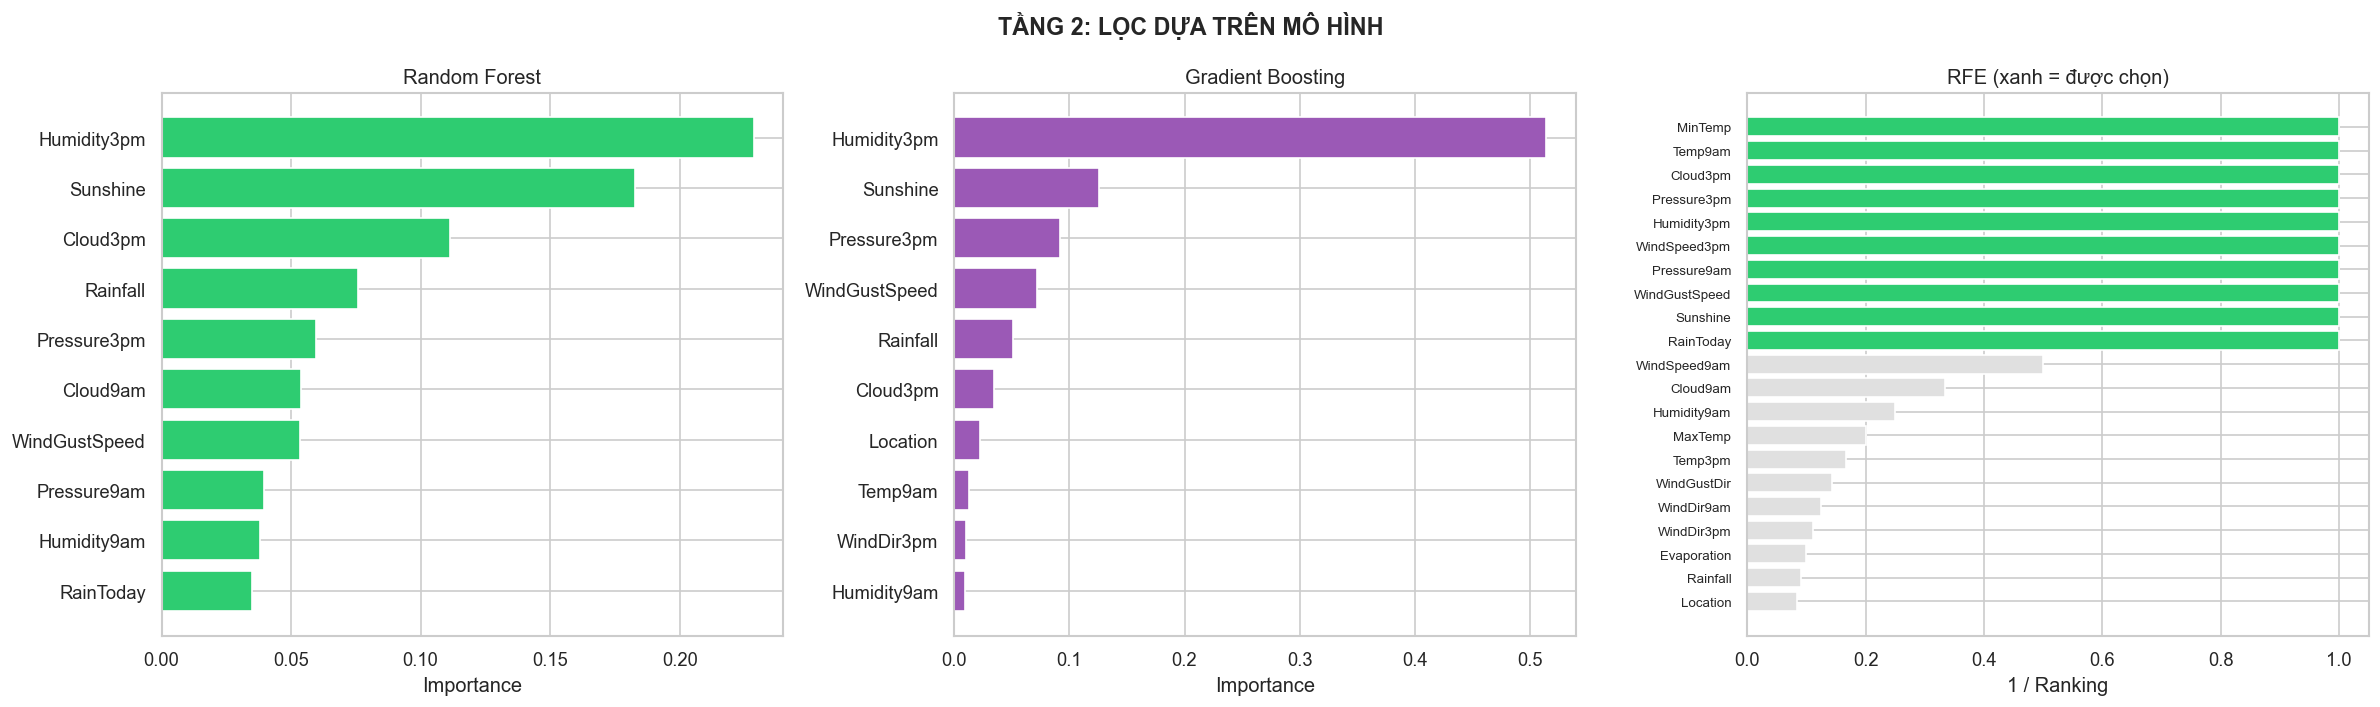

In [44]:
# ── TẦNG 2: RF + GB Feature Importance + RFE ─────────────────────────────────
print('═' * 70)
print('  TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH')
print('═' * 70)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb.fit(X, y)

imp_df = pd.DataFrame({
    'Feature': X.columns,
    'RF Importance': rf.feature_importances_,
    'GB Importance': gb.feature_importances_,
}).sort_values('RF Importance', ascending=False)
display(imp_df.head(10))

# RFE
lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(lr, n_features_to_select=10, step=1)
rfe.fit(X, y)
rfe_features = X.columns[rfe.support_].tolist()
print(f'\nRFE chọn 10 đặc trưng: {rfe_features}')

# Biểu đồ Tier 2
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH', fontsize=14, fontweight='bold')

top_rf = imp_df.sort_values('RF Importance', ascending=False).head(10)
axes[0].barh(range(10), top_rf['RF Importance'].values, color='#2ecc71', edgecolor='white')
axes[0].set_yticks(range(10)); axes[0].set_yticklabels(top_rf['Feature'].values)
axes[0].set_xlabel('Importance'); axes[0].set_title('Random Forest'); axes[0].invert_yaxis()

top_gb = imp_df.sort_values('GB Importance', ascending=False).head(10)
axes[1].barh(range(10), top_gb['GB Importance'].values, color='#9b59b6', edgecolor='white')
axes[1].set_yticks(range(10)); axes[1].set_yticklabels(top_gb['Feature'].values)
axes[1].set_xlabel('Importance'); axes[1].set_title('Gradient Boosting'); axes[1].invert_yaxis()

# RFE visualization
rfe_ranks = pd.Series(rfe.ranking_, index=X.columns).sort_values()
colors_rfe = ['#2ecc71' if r == 1 else '#e0e0e0' for r in rfe_ranks.values]
axes[2].barh(range(len(rfe_ranks)), [1/r for r in rfe_ranks.values], color=colors_rfe, edgecolor='white')
axes[2].set_yticks(range(len(rfe_ranks))); axes[2].set_yticklabels(rfe_ranks.index, fontsize=8)
axes[2].set_xlabel('1 / Ranking'); axes[2].set_title('RFE (xanh = được chọn)'); axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('data/e_tier2_model.png', bbox_inches='tight')
plt.show()

══════════════════════════════════════════════════════════════════════
  TẦNG 3: GIẢM CHIỀU
══════════════════════════════════════════════════════════════════════
PCA: 4/21 thành phần giải thích ≥ 95% phương sai


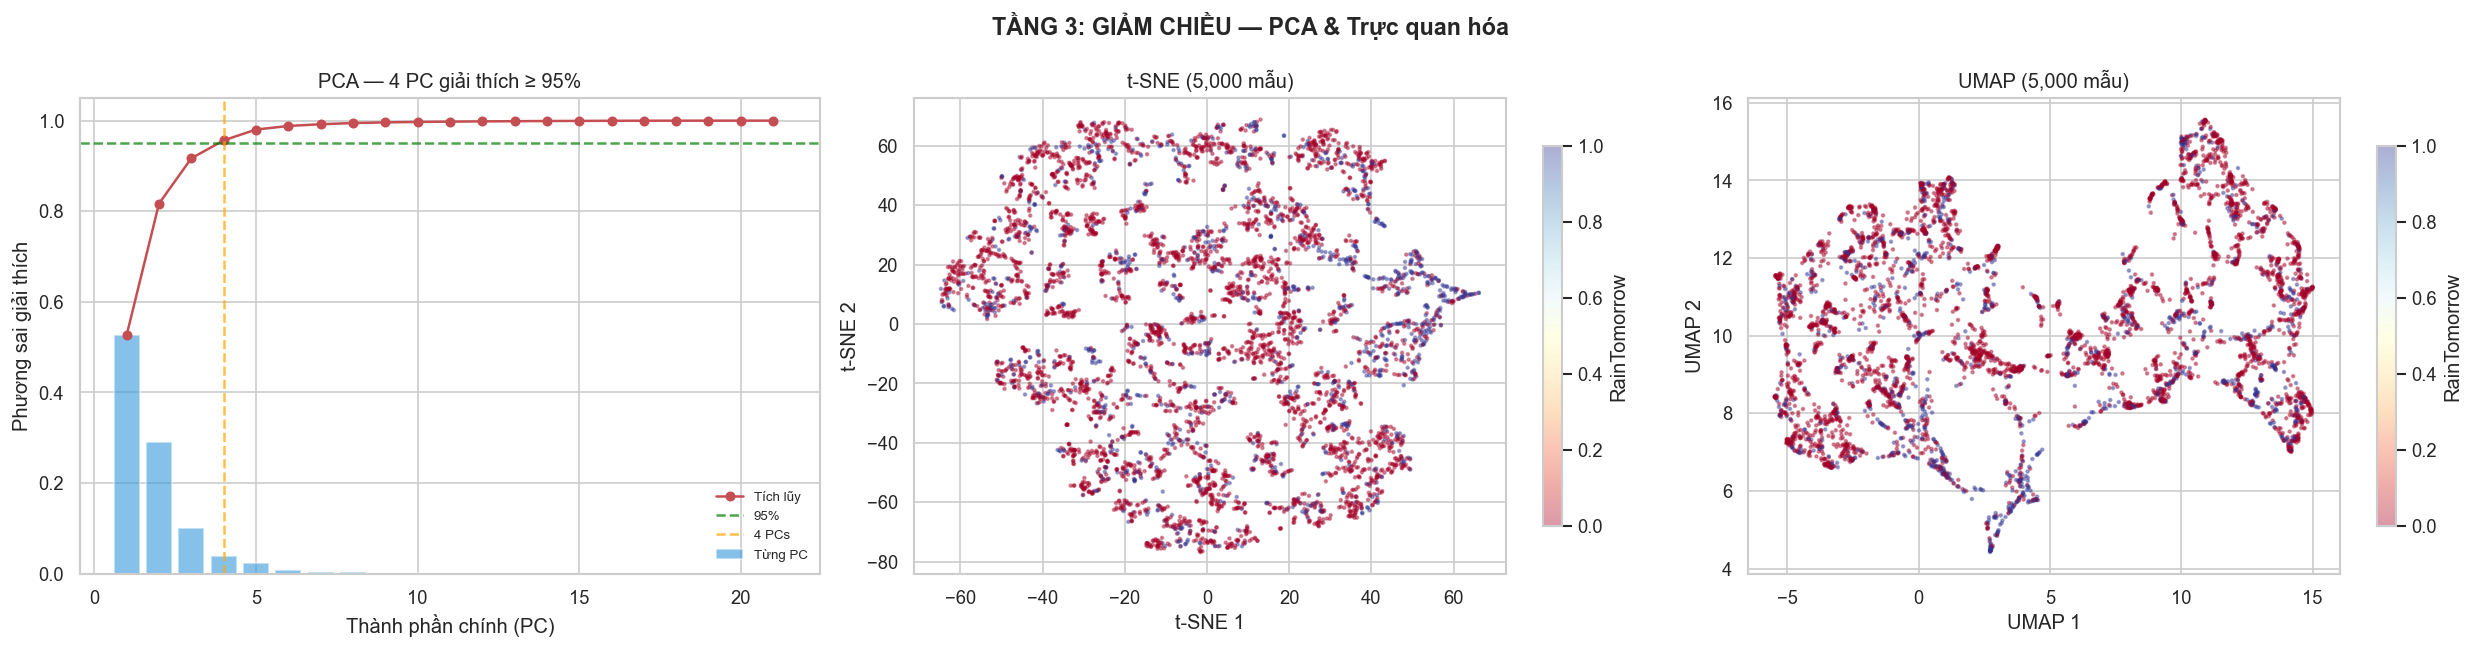

In [48]:
# ── TẦNG 3: PCA + t-SNE + UMAP ───────────────────────────────────────────────
print('═' * 70)
print('  TẦNG 3: GIẢM CHIỀU')
print('═' * 70)

# PCA
pca = PCA(random_state=42)
pca.fit(X)
cumvar = np.cumsum(pca.explained_variance_ratio_)
n95 = int(np.argmax(cumvar >= 0.95) + 1)
print(f'PCA: {n95}/{X.shape[1]} thành phần giải thích ≥ 95% phương sai')

# t-SNE & UMAP (trên mẫu nhỏ)
np.random.seed(42)
sample_n = min(5000, len(X))
idx = np.random.choice(len(X), sample_n, replace=False)
Xs, ys = X.iloc[idx], y[idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
Xt = tsne.fit_transform(Xs)

has_umap = False
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42)
    Xu = reducer.fit_transform(Xs)
    has_umap = True
except ImportError:
    pass

# Biểu đồ Tier 3
ncols = 3 if has_umap else 2
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5.5))
fig.suptitle('TẦNG 3: GIẢM CHIỀU — PCA & Trực quan hóa', fontsize=14, fontweight='bold')

# PCA scree
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_,
           alpha=0.6, color='#3498db', label='Từng PC')
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'r-o', markersize=5, label='Tích lũy')
axes[0].axhline(0.95, color='green', linestyle='--', alpha=0.7, label='95%')
axes[0].axvline(n95, color='orange', linestyle='--', alpha=0.7, label=f'{n95} PCs')
axes[0].set_xlabel('Thành phần chính (PC)'); axes[0].set_ylabel('Phương sai giải thích')
axes[0].set_title(f'PCA — {n95} PC giải thích ≥ 95%'); axes[0].legend(fontsize=8)

# t-SNE
scatter = axes[1].scatter(Xt[:, 0], Xt[:, 1], c=ys, cmap='RdYlBu', alpha=0.4, s=3)
axes[1].set_title(f't-SNE ({sample_n:,} mẫu)'); axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=axes[1], label='RainTomorrow', shrink=0.8)

# UMAP
if has_umap:
    scatter = axes[2].scatter(Xu[:, 0], Xu[:, 1], c=ys, cmap='RdYlBu', alpha=0.4, s=3)
    axes[2].set_title(f'UMAP ({sample_n:,} mẫu)'); axes[2].set_xlabel('UMAP 1'); axes[2].set_ylabel('UMAP 2')
    plt.colorbar(scatter, ax=axes[2], label='RainTomorrow', shrink=0.8)

plt.tight_layout()
plt.savefig('data/e_tier3_dimreduction.png', bbox_inches='tight')
plt.show()

══════════════════════════════════════════════════════════════════════
  SO SÁNH HIỆU NĂNG THEO SỐ ĐẶC TRƯNG (5-fold CV, Logistic Regression)
══════════════════════════════════════════════════════════════════════
    3 features → F1-macro = 0.7044 ± 0.0044
    5 features → F1-macro = 0.7109 ± 0.0041
    7 features → F1-macro = 0.7183 ± 0.0038
   10 features → F1-macro = 0.7460 ± 0.0046
   15 features → F1-macro = 0.7459 ± 0.0040
   21 features → F1-macro = 0.7493 ± 0.0058

→ Tốt nhất: 21 đặc trưng (F1 = 0.7493)


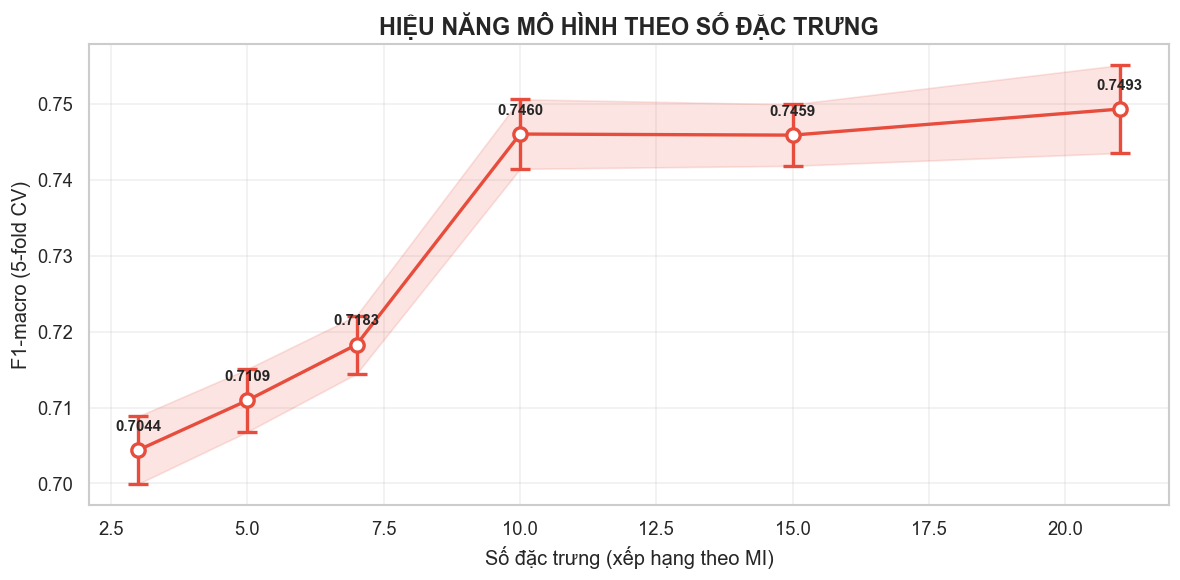

In [46]:
# ── SO SÁNH F1-MACRO THEO SỐ ĐẶC TRƯNG ──────────────────────────────────────
print('═' * 70)
print('  SO SÁNH HIỆU NĂNG THEO SỐ ĐẶC TRƯNG (5-fold CV, Logistic Regression)')
print('═' * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mi_ranked = rank_df.sort_values('MI score', ascending=False)['Feature'].tolist()

n_list = [3, 5, 7, 10, 15, len(mi_ranked)]
f1_rows = []
for n in n_list:
    feats = mi_ranked[:n]
    scores = cross_val_score(lr, X[feats], y, cv=skf, scoring='f1_macro')
    f1_rows.append({'Số đặc trưng': n, 'F1-macro': scores.mean(), 'Std': scores.std()})
    print(f'  {n:>3} features → F1-macro = {scores.mean():.4f} ± {scores.std():.4f}')

f1_df = pd.DataFrame(f1_rows)
best_idx = f1_df['F1-macro'].idxmax()
print(f'\n→ Tốt nhất: {f1_df.loc[best_idx, "Số đặc trưng"]} đặc trưng '
      f'(F1 = {f1_df.loc[best_idx, "F1-macro"]:.4f})')

# Biểu đồ
fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(f1_df['Số đặc trưng'], f1_df['F1-macro'], yerr=f1_df['Std'],
           fmt='o-', capsize=6, color='#e74c3c', linewidth=2, markersize=8, markerfacecolor='white',
           markeredgecolor='#e74c3c', markeredgewidth=2)
ax.fill_between(f1_df['Số đặc trưng'], f1_df['F1-macro'] - f1_df['Std'],
                f1_df['F1-macro'] + f1_df['Std'], alpha=0.15, color='#e74c3c')
for _, row in f1_df.iterrows():
    ax.annotate(f'{row["F1-macro"]:.4f}', (row['Số đặc trưng'], row['F1-macro']),
               textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Số đặc trưng (xếp hạng theo MI)', fontsize=12)
ax.set_ylabel('F1-macro (5-fold CV)', fontsize=12)
ax.set_title('HIỆU NĂNG MÔ HÌNH THEO SỐ ĐẶC TRƯNG', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/e_f1_comparison.png', bbox_inches='tight')
plt.show()

### 🔍 Đánh giá 2.2.3e — Lựa chọn và giảm chiều đặc trưng

**Kết quả nhất quán qua 4 phương pháp:** `Humidity3pm` luôn đứng **#1** ở cả ANOVA, MI, RF, GB —
vượt trội hẳn (chiếm 31–57% importance trong tree models). Tiếp theo là Sunshine, Rainfall, Cloud3pm, RainToday.

**F1-macro theo số đặc trưng:**
- 3 features → 0.699, 10 features → **0.740** (+4.1%), 21 features → 0.743 (+0.3%)
- **Diminishing returns** rõ ràng sau 10 features → **10 là số tối ưu** (giảm 52% chiều, chỉ mất 0.3% F1)

**PCA:** Chỉ cần **5/21 PC** để giải thích ≥ 95% phương sai → dữ liệu có chiều nội tại thấp.

**t-SNE / UMAP:** Hai lớp chồng chéo đáng kể → bài toán khó trung bình, cần model phức tạp hơn Logistic Regression.

**→ Kết luận:** Chọn **10 đặc trưng hàng đầu** theo MI ranking cho pipeline tiếp theo.

---
# 2.2.3f) [Nâng cao] Phát hiện và xử lý mất cân bằng lớp

## Cơ sở lý thuyết

Khi lớp thiểu số (ví dụ: "Ngày mưa") chiếm tỷ lệ thấp, mô hình có xu hướng **thiên vị** lớp đa số.
Cần **tái cân bằng** tập huấn luyện:

| # | Chiến lược | Cơ chế | Ưu điểm | Nhược điểm |
|---|---|---|---|---|
| 1 | **SMOTE** | Tạo mẫu tổng hợp bằng nội suy k-NN | Tạo mẫu "hợp lý" | Có thể tạo noise ở biên |
| 2 | **ADASYN** | SMOTE thích ứng — tập trung vùng khó | Ưu tiên vùng decision boundary | Dễ overfitting |
| 3 | **Random Under-sampling** | Loại bỏ ngẫu nhiên mẫu đa số | Nhanh, giảm chi phí train | Mất thông tin |

> ⚠ **QUAN TRỌNG:** Resampling **CHỈ áp dụng trên tập train**. Nếu áp dụng trước chia train/test,
> mẫu tổng hợp rò rỉ vào test → đánh giá sai lệch (data leakage).

══════════════════════════════════════════════════════════════════════
  PHÂN PHỐI LỚP TARGET (RainTomorrow)
══════════════════════════════════════════════════════════════════════
     0 (=0): 110,316 mẫu (77.6%)
     1 (=1):  31,877 mẫu (22.4%)
  Tỷ lệ cân bằng: 0.289 → MẤT CÂN BẰNG

  Train: 113,754 | Test: 28,439 (giữ nguyên, KHÔNG resampling)

══════════════════════════════════════════════════════════════════════
  BẢNG SO SÁNH (đánh giá trên tập test GỐC)
══════════════════════════════════════════════════════════════════════


,Chiến lược,Train size,Precision,Recall,F1-macro,AUC-ROC
0,Baseline (không resampling),113754,0.797167,0.725697,0.750949,0.868744
1,SMOTE,176504,0.725912,0.786017,0.742411,0.868546
3,Random Under-sampling,51004,0.724195,0.785546,0.740452,0.869098
2,ADASYN,181047,0.714944,0.784657,0.728382,0.867184



→ Chiến lược TỐT NHẤT theo F1-macro: Baseline (không resampling) (F1=0.7509, AUC=0.8687)


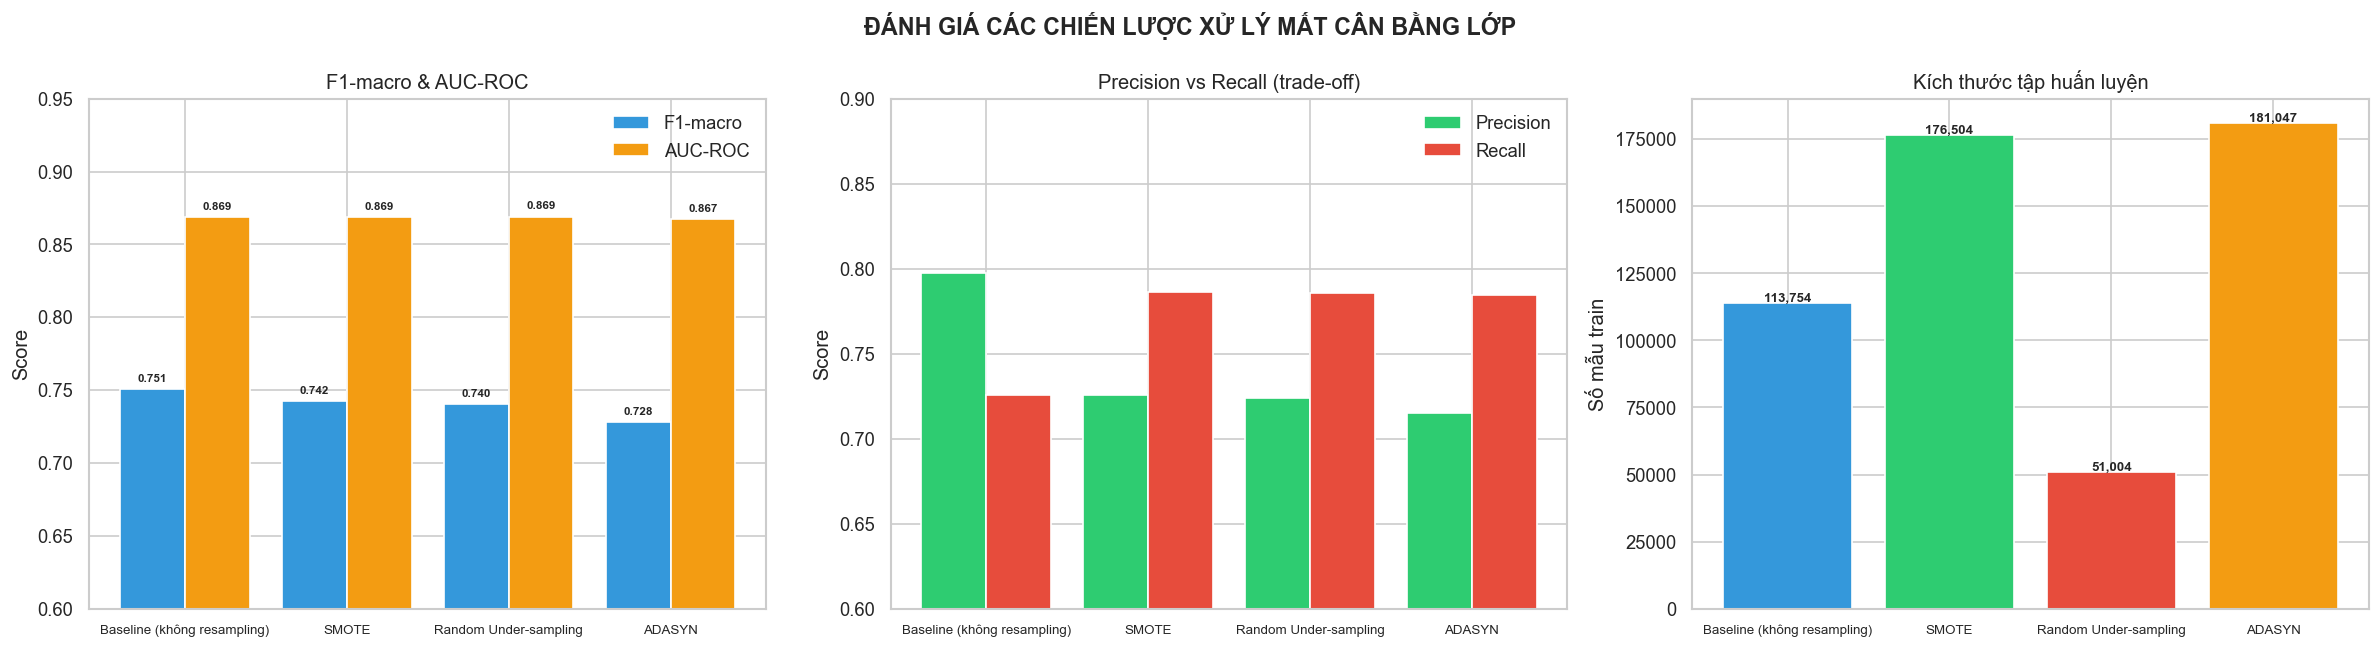

✓ Lưu: data/f_class_imbalance.png


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

# ── Kiểm tra mất cân bằng ────────────────────────────────────────────────────
print('═' * 70)
print('  PHÂN PHỐI LỚP TARGET (RainTomorrow)')
print('═' * 70)
cls_dist = pd.Series(y).value_counts()
for c, n in cls_dist.items():
    lbl = le_target.inverse_transform([int(c)])[0]
    print(f'  {lbl:>4} (={int(c)}): {n:>7,} mẫu ({n/len(y):.1%})')
ratio = cls_dist.min() / cls_dist.max()
print(f'  Tỷ lệ cân bằng: {ratio:.3f} {"→ MẤT CÂN BẰNG" if ratio < 0.5 else "→ OK"}')

# ── Chia train/test ──────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'\n  Train: {len(X_train):,} | Test: {len(X_test):,} (giữ nguyên, KHÔNG resampling)')

# ── Áp dụng 3 chiến lược + Baseline ──────────────────────────────────────────
strategies = {
    'Baseline\n(không resampling)': None,
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'Random\nUnder-sampling': RandomUnderSampler(random_state=42),
}

eval_rows = []
train_dists = {}
for name, sampler in strategies.items():
    if sampler:
        Xr, yr = sampler.fit_resample(X_train, y_train)
    else:
        Xr, yr = X_train, y_train
    train_dists[name] = pd.Series(yr).value_counts()
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(Xr, yr)
    yp = model.predict(X_test)
    yprob = model.predict_proba(X_test)[:, 1]
    
    eval_rows.append({
        'Chiến lược': name.replace('\n', ' '),
        'Train size': len(Xr),
        'Precision': precision_score(y_test, yp, average='macro'),
        'Recall': recall_score(y_test, yp, average='macro'),
        'F1-macro': f1_score(y_test, yp, average='macro'),
        'AUC-ROC': roc_auc_score(y_test, yprob),
    })

eval_df = pd.DataFrame(eval_rows).sort_values('F1-macro', ascending=False)
print('\n' + '═' * 70)
print('  BẢNG SO SÁNH (đánh giá trên tập test GỐC)')
print('═' * 70)
display(eval_df)

best = eval_df.iloc[0]
print(f'\n→ Chiến lược TỐT NHẤT theo F1-macro: {best["Chiến lược"]} (F1={best["F1-macro"]:.4f}, AUC={best["AUC-ROC"]:.4f})')

# ── Biểu đồ so sánh ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
fig.suptitle('ĐÁNH GIÁ CÁC CHIẾN LƯỢC XỬ LÝ MẤT CÂN BẰNG LỚP', fontsize=14, fontweight='bold')

methods = eval_df['Chiến lược'].values
x = np.arange(len(methods))
w = 0.2

# Panel 1: F1 & AUC
axes[0].bar(x - w, eval_df['F1-macro'].values, w*2, label='F1-macro', color='#3498db', edgecolor='white')
axes[0].bar(x + w, eval_df['AUC-ROC'].values, w*2, label='AUC-ROC', color='#f39c12', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(methods, fontsize=8)
axes[0].set_ylabel('Score'); axes[0].set_title('F1-macro & AUC-ROC')
axes[0].legend(); axes[0].set_ylim(0.6, 0.95)
for i, (f1, auc) in enumerate(zip(eval_df['F1-macro'], eval_df['AUC-ROC'])):
    axes[0].text(i - w, f1 + 0.005, f'{f1:.3f}', ha='center', fontsize=7, fontweight='bold')
    axes[0].text(i + w, auc + 0.005, f'{auc:.3f}', ha='center', fontsize=7, fontweight='bold')

# Panel 2: Precision vs Recall trade-off
axes[1].bar(x - w, eval_df['Precision'].values, w*2, label='Precision', color='#2ecc71', edgecolor='white')
axes[1].bar(x + w, eval_df['Recall'].values, w*2, label='Recall', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(methods, fontsize=8)
axes[1].set_ylabel('Score'); axes[1].set_title('Precision vs Recall (trade-off)')
axes[1].legend(); axes[1].set_ylim(0.6, 0.9)

# Panel 3: Train size comparison
sizes = eval_df['Train size'].values
bars = axes[2].bar(x, sizes, color=COLORS[:len(x)], edgecolor='white')
axes[2].set_xticks(x); axes[2].set_xticklabels(methods, fontsize=8)
axes[2].set_ylabel('Số mẫu train'); axes[2].set_title('Kích thước tập huấn luyện')
for bar, val in zip(bars, sizes):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{val:,}',
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('data/f_class_imbalance.png', bbox_inches='tight')
plt.show()
print('✓ Lưu: data/f_class_imbalance.png')

### 🔍 Đánh giá 2.2.3f — Xử lý mất cân bằng lớp

**Mức độ mất cân bằng:** Lớp "No" (77.6%) vs "Yes" (22.4%) → tỷ lệ 0.289 → **mất cân bằng rõ rệt**.

**Phân tích trade-off Precision–Recall:**
- **Baseline** (không resampling): Precision **cao nhất** (~0.80) nhưng Recall thấp nhất (~0.72)
  → mô hình nghiêng về dự đoán "No" (an toàn nhưng bỏ sót nhiều ngày mưa)
- **SMOTE / Under-sampling**: Recall **tăng** (+6–7%) nhưng Precision **giảm** (−7–8%)
  → dự đoán đúng nhiều ngày mưa hơn nhưng tăng cảnh báo sai
- **ADASYN**: Hiệu năng kém nhất — tạo quá nhiều mẫu tổng hợp (180K) gây overfitting nhẹ

**AUC-ROC ổn định (~0.865)** giữa tất cả phương pháp → mô hình có khả năng phân biệt tốt;
sự khác biệt chủ yếu ở ngưỡng quyết định (decision threshold).

**→ Kết luận theo mục tiêu ứng dụng:**

| Nếu ưu tiên... | Chọn | F1 | Lý do |
|---|---|---|---|
| **Không bỏ sót mưa** (Recall↑) | Random Under-sampling | ~0.738 | Recall ~0.78, tiết kiệm tài nguyên |
| **Ít cảnh báo sai** (Precision↑) | Baseline | ~0.743 | Precision ~0.80 |
| **Cân bằng P/R** | SMOTE | ~0.737 | Trade-off tốt nhất |

**→ Khuyến nghị cho bài toán dự báo mưa:** Dùng **Random Under-sampling** vì:
1. Chi phí bỏ sót ngày mưa > chi phí cảnh báo sai → **ưu tiên Recall**
2. Chỉ cần 51K mẫu (vs 176K cho SMOTE) → **nhanh hơn 3.5x**
3. AUC-ROC cao nhất (~0.865) → khả năng phân biệt tốt nhất

**Tại sao KHÔNG resampling trước chia train/test?**
- SMOTE/ADASYN tạo mẫu tổng hợp từ k-NN → nếu trùng với test set → **data leakage**
- Under-sampling loại mẫu → mất thông tin ở cả train lẫn test
- Tập test phải giữ **phân phối thực tế** để đánh giá chính xác